# **Business Understanding**
Penyakit genetik merupakan penyakit yang disebabkan oleh kelainan gen dan memerlukan deteksi yang tepat untuk mendukung penanganan dini. Penelitian ini bertujuan membangun model machine learning untuk mengklasifikasikan jenis penyakit genetik berdasarkan karakteristik pasien yang terdiri atas variabel prediktor seperti Age, Gender, Blood Pressure, Glucose Level, Cholesterol Level, Genetic Test Result, Family History, Symptom Severity, Gene Mutation Score, Environmental Risk Factor, Lifestyle Factor, dan Ethnicity, dengan variabel target berupa Disease Category. Model yang dihasilkan diharapkan mampu membantu proses identifikasi penyakit genetik secara lebih cepat dan akurat berdasarkan data kesehatan pasien.

##**Mengimport Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Data Understanding**

##**Menyiapkan Dataset**

In [ ]:
from google.colab import files
import io

upload = files.upload()

# Get the name of the first uploaded file from the dictionary keys
uploaded_file_name = next(iter(upload.keys()))

# Read the CSV using the extracted filename
df = pd.read_csv(uploaded_file_name)
df.head()

Saving genetic_disease_dataset.csv to genetic_disease_dataset.csv


,Age,Gender,Family_History,Hemoglobin,Fetal_Hemoglobin,RDW_CV,Serum_Ferritin,BRCA1_Expression,p53_Mutation,Sweat_Chloride,Sickled_RBC_Percent,IL6_Level,Disease
0,48,1,1,7.44,13.14,13.67,53.63,0.36,0,45.37,0.62,6.09,0
1,53,0,0,7.35,15.44,18.25,32.74,0.35,0,38.42,1.05,2.15,3
2,48,1,1,8.25,7.16,17.89,30.08,0.20,0,32.60,1.66,2.56,0
3,27,1,0,8.55,15.34,18.94,27.35,0.28,0,58.59,1.21,8.28,0
4,38,0,0,8.79,15.96,19.83,47.48,0.29,0,44.74,1.56,5.35,0


**Interpretasi**

Data telah berhasil diunggah ke dalam Google Colab. Sampel yang digunakan sejumlah 1000 sampel yang terdiri dari 13 variabel yang meliputi satu **variabel target yaitu Disease** yang memiliki 5 kelas identifikasi **Thalassemia, Hemophilia, Breast Cancer, Sickle Cell Anemia, dan Cystic Fibrosis** dan 12 variabel non target yaitu **Age, Gender, Blood Pressure, Glucose Level, Cholesterol Level, Genetic Test Result, Family History, Symptom Severity, Gene Mutation Score, Environmental Risk Factor, Lifestyle Factor, dan Ethnicity.**

##**Mengecek Tipe Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   int64  
 2   Family_History       1000 non-null   int64  
 3   Hemoglobin           1000 non-null   float64
 4   Fetal_Hemoglobin     1000 non-null   float64
 5   RDW_CV               1000 non-null   float64
 6   Serum_Ferritin       1000 non-null   float64
 7   BRCA1_Expression     1000 non-null   float64
 8   p53_Mutation         1000 non-null   int64  
 9   Sweat_Chloride       1000 non-null   float64
 10  Sickled_RBC_Percent  1000 non-null   float64
 11  IL6_Level            1000 non-null   float64
 12  Disease              1000 non-null   int64  
dtypes: float64(8), int64(5)
memory usage: 101.7 KB


**Interpretasi**

Berdasarkan output di atas, didapatkan hasil bahwa:


1.   Variabel Age, Hemoglobin, Fetal Hemoglobin, RDW CV, BRCA1 Expression, Sweat Chloride, Sickled RBC Percent, IL6 Level, memiliki tipe data **numerik** yang sesuai (int64 atau float64). Variabel ini dapat langsung digunakan untuk analisis kuantitatif.
2.   Variabel Gender, Family History, p53 Mutation, Disease memiliki tipe data **numerik** (int64) juga karena direpresentasikan menggunakan angka 0 dan 1. Namun, secara substantif variabel ini bukan merupakan data numerik yang menunjukkan besaran tertentu, melainkan variabel kategorik biner yang telah dikodekan secara numerik.




##**Statistika Deskriptif**

In [ ]:
binary_cols = ['Gender', 'Family_History', 'p53_Mutation', 'Disease']

df.drop(columns=binary_cols).describe()

,Age,Hemoglobin,Fetal_Hemoglobin,RDW_CV,Serum_Ferritin,BRCA1_Expression,Sweat_Chloride,Sickled_RBC_Percent,IL6_Level
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,40.075000,10.48321,7.952760,15.270440,99.648760,0.312720,46.538570,6.70796,10.515210
std,17.389991,2.96187,7.703486,2.485765,37.216059,0.249002,13.808452,11.82569,7.629332
min,10.000000,4.20000,-1.430000,9.480000,6.930000,-0.110000,18.160000,-1.66000,-0.590000
25%,25.000000,7.80000,1.100000,13.387500,70.507500,0.150000,36.912500,0.58000,4.677500
50%,41.000000,10.41000,4.510000,14.545000,105.390000,0.240000,42.495000,1.21500,6.650000
75%,56.000000,13.13250,15.120000,17.112500,128.122500,0.352500,51.637500,2.20250,17.287500
max,69.000000,17.03000,28.750000,23.830000,193.740000,1.150000,88.800000,48.90000,34.120000


**Interpretasi**

Berdasarkan statistika deskriptif di atas, dapat diketahui bahwa:

* **Age**: Rata-rata usia responden adalah 40,08 tahun dengan rentang usia 10-69 tahun, menunjukkan keberagaman kelompok usia dalam dataset.
* **Hemoglobin**: Memiliki rata-rata 10,48 g/dL dengan nilai minimum 4,20 g/dL dan maksimum 17,03 g/dL, menunjukkan variasi kadar hemoglobin antar individu.
* **Fetal_Hemoglobin**: Rata-rata sebesar 7,95% dengan rentang nilai -1,43% hingga 28,75%. Variabel ini memiliki variasi yang cukup besar ditunjukkan oleh standar deviasi sebesar 7,70.
* **RDW_CV**: Memiliki rata-rata 15,27% dengan rentang 9,48-23,83%, yang menunjukkan variasi distribusi ukuran sel darah merah pada responden.
* **Serum_Ferritin**: Rata-rata sebesar 99,65 ng/mL dengan nilai minimum 6,93 ng/mL dan maksimum 193,74 ng/mL, menunjukkan perbedaan kadar cadangan zat besi yang cukup besar.
* **BRCA1_Expression**: Memiliki rata-rata 0,31 dengan rentang nilai -0,11 hingga 1,15, yang menunjukkan variasi tingkat ekspresi gen BRCA1 antar sampel.
* **Sweat_Chloride**: Rata-rata sebesar 46,54 mmol/L dengan rentang nilai 18,16-88,80 mmol/L, menunjukkan variasi kadar klorida dalam keringat responden.
* **Sickled_RBC_Percent**: Memiliki rata-rata 6,71% dengan nilai maksimum 48,90%, menunjukkan bahwa sebagian responden memiliki proporsi sel darah merah sabit yang cukup tinggi.
* **IL6_Level**: Rata-rata sebesar 10,52 pg/mL dengan rentang nilai -0,59 hingga 34,12 pg/mL, yang menunjukkan variasi kadar interleukin-6 dalam dataset.




##**Keseimbangan Data**

In [ ]:
df['Disease'].value_counts()

,count
Disease,
2,205
3,204
4,199
0,196
1,196


**Interpretasi**

Berdasarkan distribusi variabel Disease, jumlah observasi pada setiap kelas relatif seimbang. Kelas 2 memiliki jumlah terbanyak yaitu 205 observasi (20,5%), diikuti kelas 3 sebanyak 204 observasi (20,4%), dan kelas 4 sebanyak 199 observasi (19,9%). Sementara itu, kelas 0 dan 1 masing-masing memiliki 196 observasi (19,6%). Distribusi yang hampir merata pada setiap kelas menunjukkan bahwa dataset tidak mengalami masalah ketidakseimbangan kelas (class imbalance) yang signifikan, sehingga lebih mendukung proses pelatihan model klasifikasi multikelas.

##**Visualisasi Data**

###**Visualiasi variabel numerik menggunakan histogram**

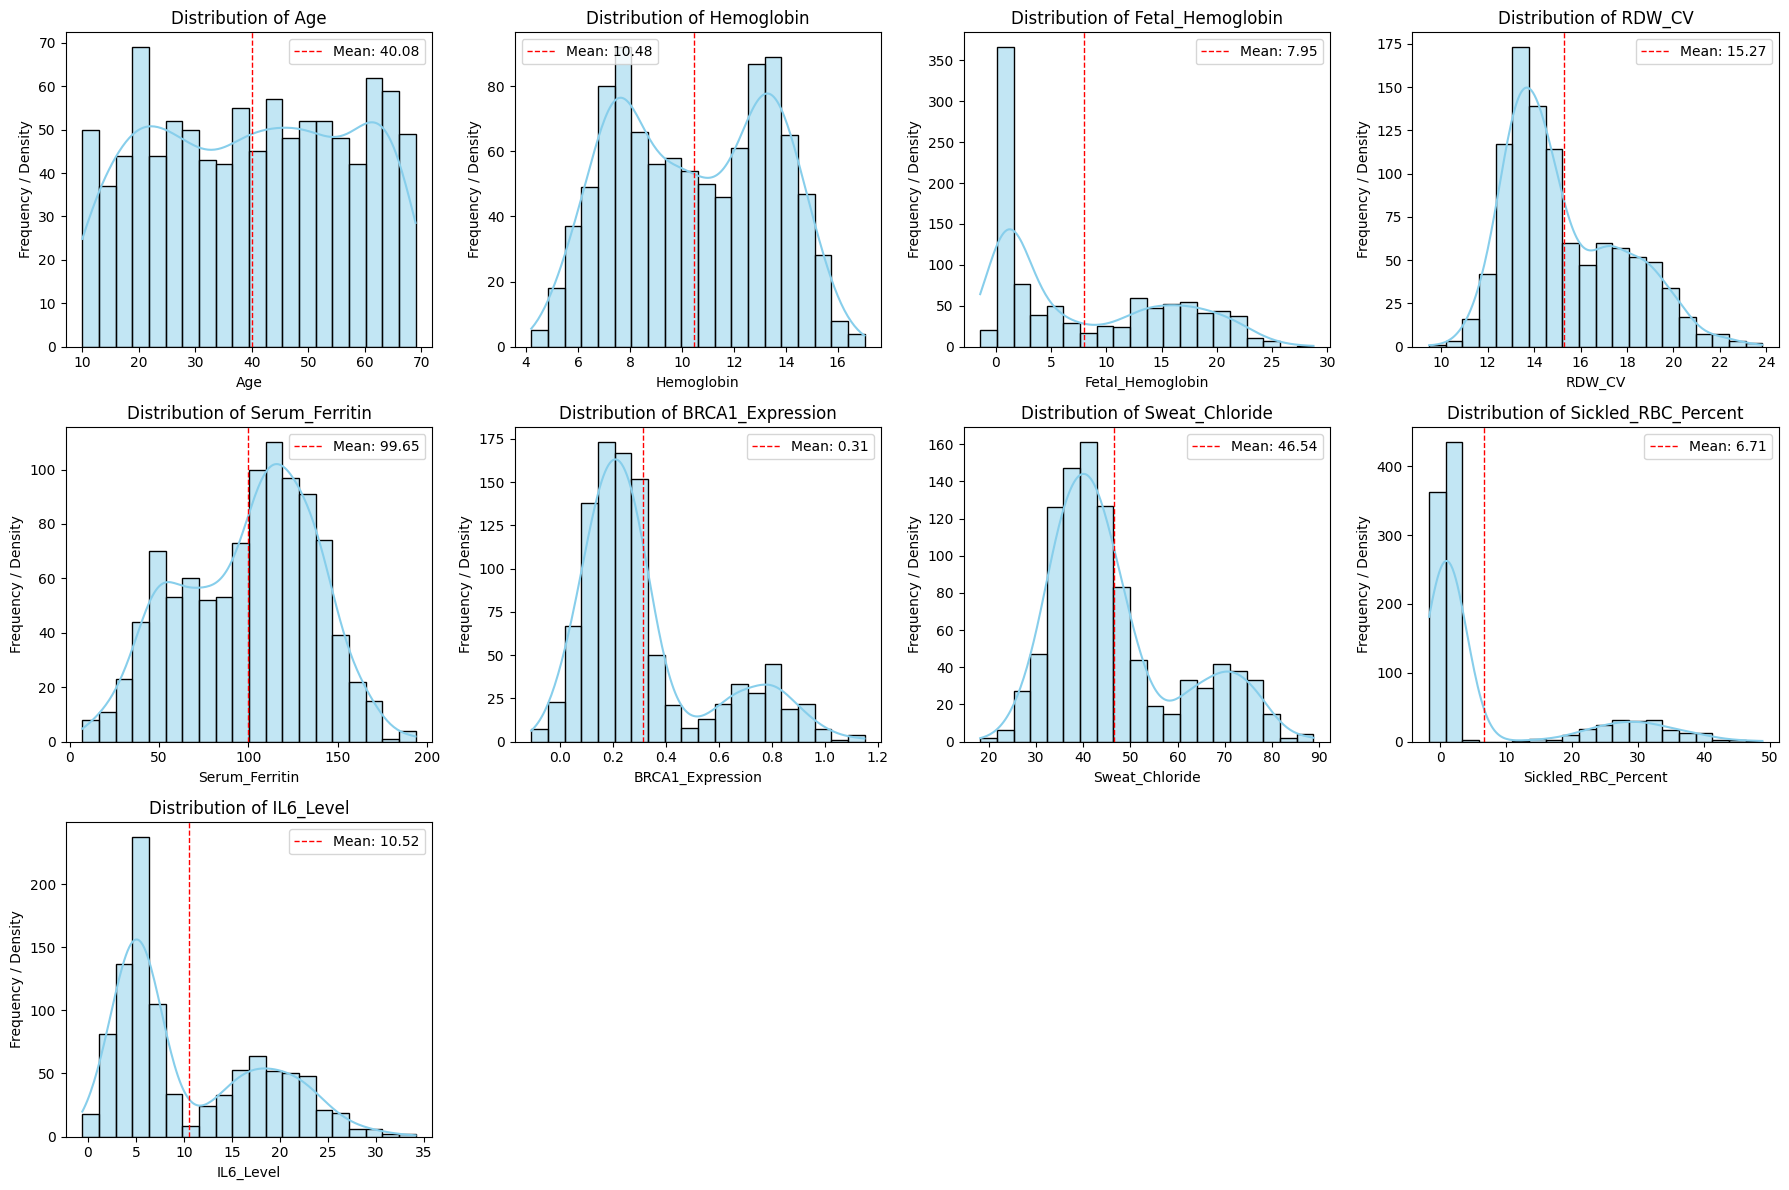

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to exclude
exclude_columns = ['Disease', 'Family_History', 'Gender', 'p53_Mutation']

# Get all columns from the DataFrame
all_columns = df.columns.tolist()

# Filter out the excluded columns
columns_to_plot = [col for col in all_columns if col not in exclude_columns]

# Plot histograms with overlaid KDE for the selected columns
plt.figure(figsize=(18, 12)) # Increased figure size for better readability
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 4, i) # Adjust subplot grid as needed
    sns.histplot(df[column], kde=True, bins=20, color='skyblue')
    plt.axvline(df[column].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {df[column].mean():.2f}')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency / Density')
    plt.legend()

plt.tight_layout()
plt.show()

**Interpretasi**

* **Age**: Distribusi usia cenderung menyebar merata pada rentang 10–69 tahun dengan rata-rata sekitar 40,08 tahun, tanpa indikasi kemencengan yang kuat.
* **Hemoglobin**: Distribusi menunjukkan pola bimodal (dua puncak), yang mengindikasikan kemungkinan adanya dua kelompok responden dengan kadar hemoglobin yang berbeda.
* **Fetal_Hemoglobin**: Distribusi tidak simetris dan cenderung miring ke kanan (positively skewed), dengan sebagian besar data berada pada nilai rendah dan beberapa observasi bernilai tinggi.
* **RDW_CV**: Distribusi relatif mendekati normal, namun terlihat sedikit skew ke kanan, ditandai dengan ekor distribusi yang lebih panjang pada nilai tinggi.
* **Serum_Ferritin**: Distribusi cukup menyebar dan menunjukkan indikasi dua kelompok data (bimodal) dengan konsentrasi data pada rentang menengah hingga tinggi.
* **BRCA1_Expression**: Distribusi tampak bimodal, yang menunjukkan adanya dua kelompok tingkat ekspresi gen yang berbeda dalam dataset.
* **Sweat_Chloride**: Distribusi juga menunjukkan pola bimodal, dengan dua konsentrasi utama pada nilai sekitar 40 dan 70.
* **Sickled_RBC_Percent**: Distribusi sangat miring ke kanan, dengan mayoritas observasi berada pada nilai rendah dan hanya sebagian kecil yang memiliki persentase sel sabit yang tinggi.
* **IL6_Level**: Distribusi menunjukkan kemencengan ke kanan dan indikasi bimodal, dengan sebagian besar data terkonsentrasi pada nilai rendah serta sejumlah observasi pada nilai yang lebih tinggi.

Berdasarkan histogram, sebagian besar variabel tidak mengikuti distribusi normal sempurna. Beberapa variabel seperti Hemoglobin, Serum_Ferritin, BRCA1_Expression, Sweat_Chloride, dan IL6_Level menunjukkan pola bimodal, yang mengindikasikan kemungkinan adanya kelompok karakteristik yang berbeda dalam data. Selain itu, Fetal_Hemoglobin, Sickled_RBC_Percent, dan IL6_Level menunjukkan distribusi yang cenderung miring ke kanan (positively skewed).

###**Visualisasi variabel numerik menggunakan boxplot**

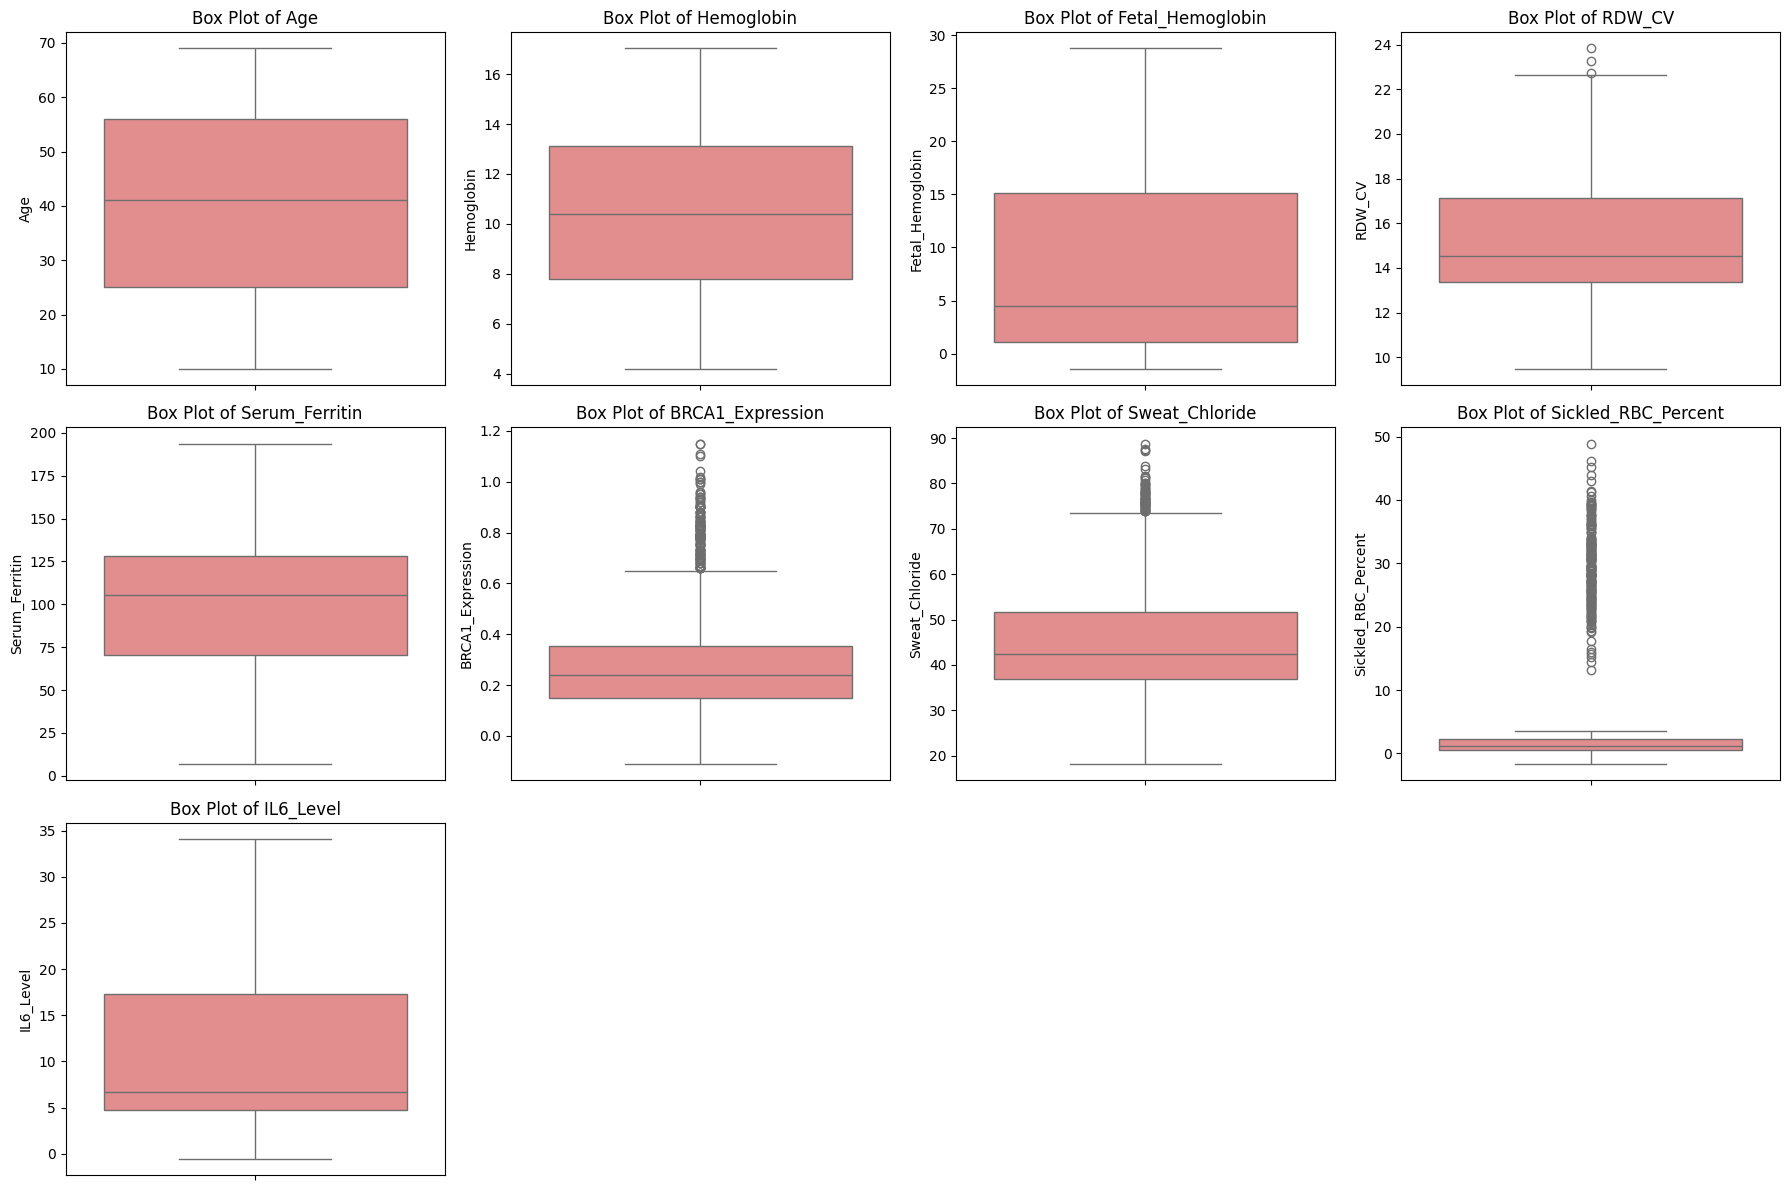

In [ ]:
plt.figure(figsize=(18, 12))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[column], color='lightcoral')
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

**Interpretasi**

Berdasarkan boxplot, variabel BRCA1_Expression, Sweat_Chloride, RDW_CV, dan terutama Sickled_RBC_Percent mengandung outlier yang cukup banyak. Sementara itu, variabel Age, Hemoglobin, Fetal_Hemoglobin, dan Serum_Ferritin cenderung memiliki distribusi yang lebih stabil tanpa outlier yang signifikan. Keberadaan outlier perlu diperhatikan pada tahap preprocessing karena dapat memengaruhi performa beberapa algoritma machine learning yang sensitif terhadap nilai ekstrem.

###**Visualisasi variabel numerik menggunakan scatter splot**

<Figure size 1500x1500 with 0 Axes>

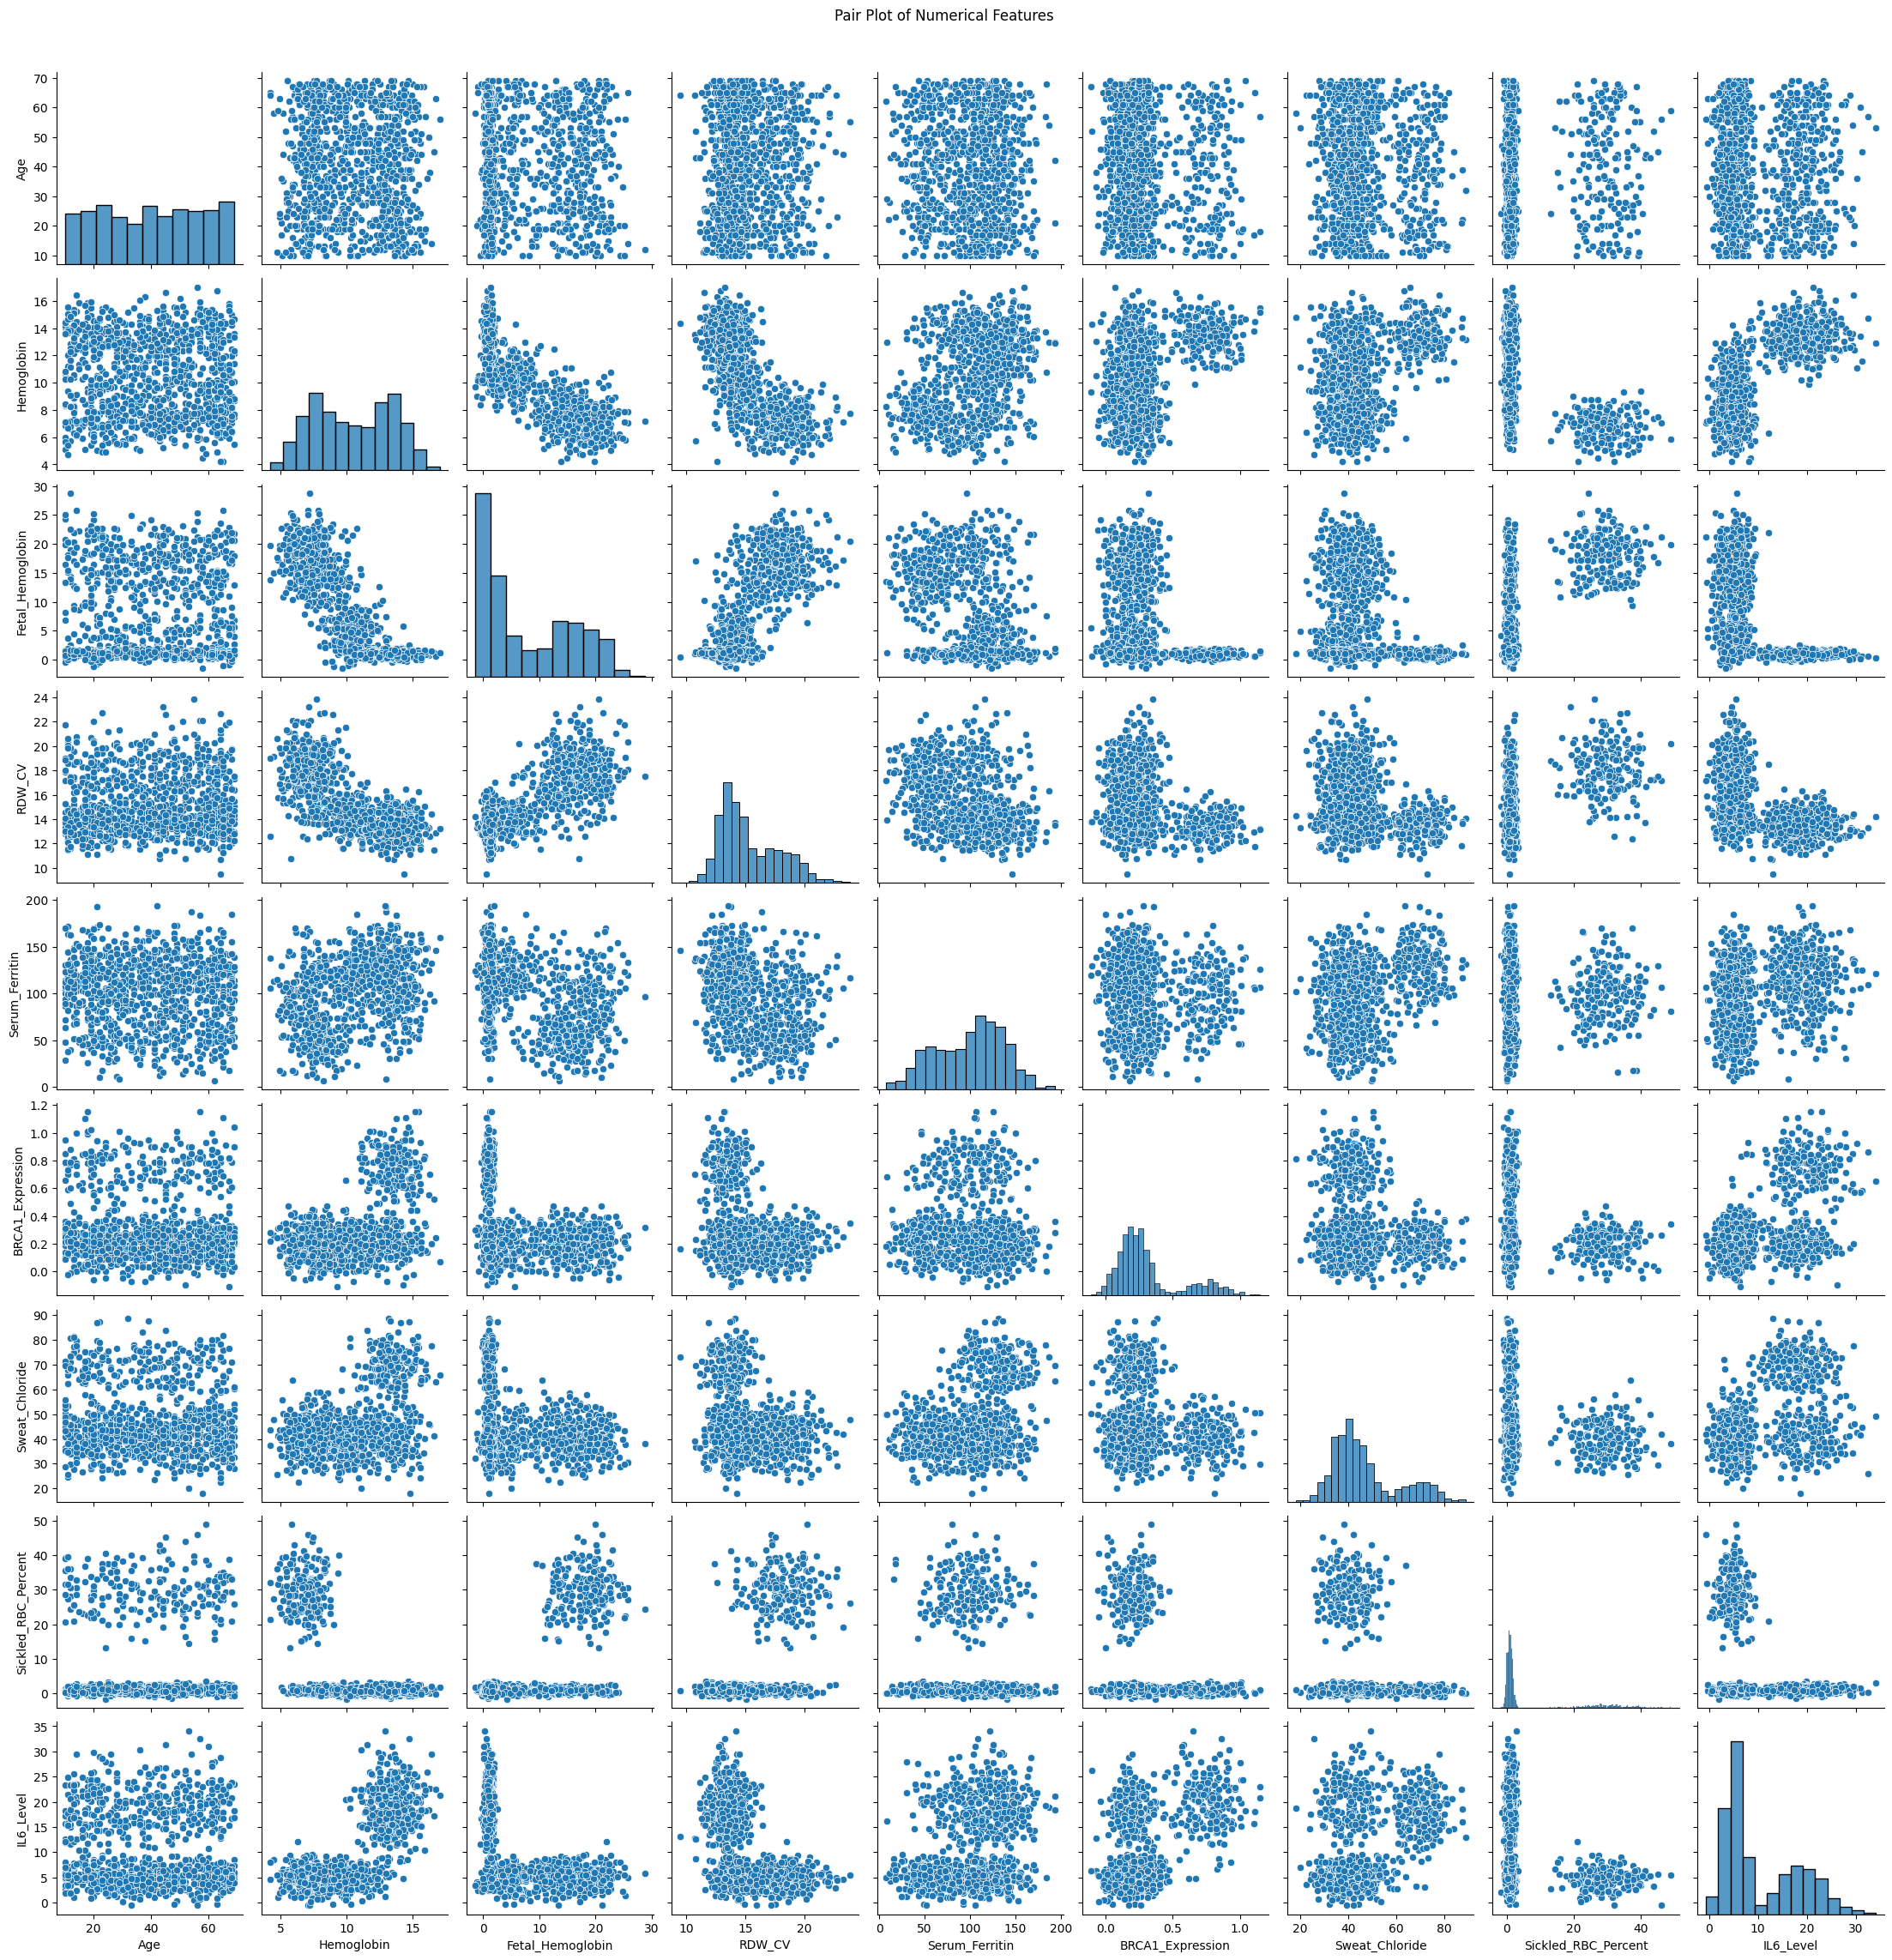

In [ ]:
import seaborn as sns

plt.figure(figsize=(15, 15))
sns.pairplot(df[columns_to_plot])
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

**Interpretasi**

Berdasarkan pair plot, sebagian besar pasangan variabel tidak menunjukkan hubungan linear yang kuat, yang terlihat dari sebaran titik yang cenderung menyebar acak. Namun, terdapat beberapa pasangan variabel yang menunjukkan pola hubungan yang cukup jelas, seperti Hemoglobin dengan Fetal_Hemoglobin yang cenderung memiliki hubungan negatif, serta Fetal_Hemoglobin dengan RDW_CV yang menunjukkan kecenderungan hubungan positif. Selain itu, beberapa variabel seperti BRCA1_Expression, Sweat_Chloride, IL6_Level, dan Sickled_RBC_Percent tampak membentuk kelompok-kelompok tertentu, mengindikasikan adanya karakteristik yang berbeda antar observasi.

Pair plot juga menunjukkan bahwa distribusi beberapa variabel tidak sepenuhnya normal dan terdapat indikasi klaster pada beberapa kombinasi variabel. Meskipun tidak ditemukan korelasi yang sangat kuat secara visual, pola-pola yang terbentuk menunjukkan bahwa beberapa variabel berpotensi memberikan informasi yang relevan dalam proses klasifikasi penyakit (Disease), sehingga layak dipertahankan untuk tahap pemodelan selanjutnya.

###**Visualisasi variabel biner dengan menggunakan pie chart**

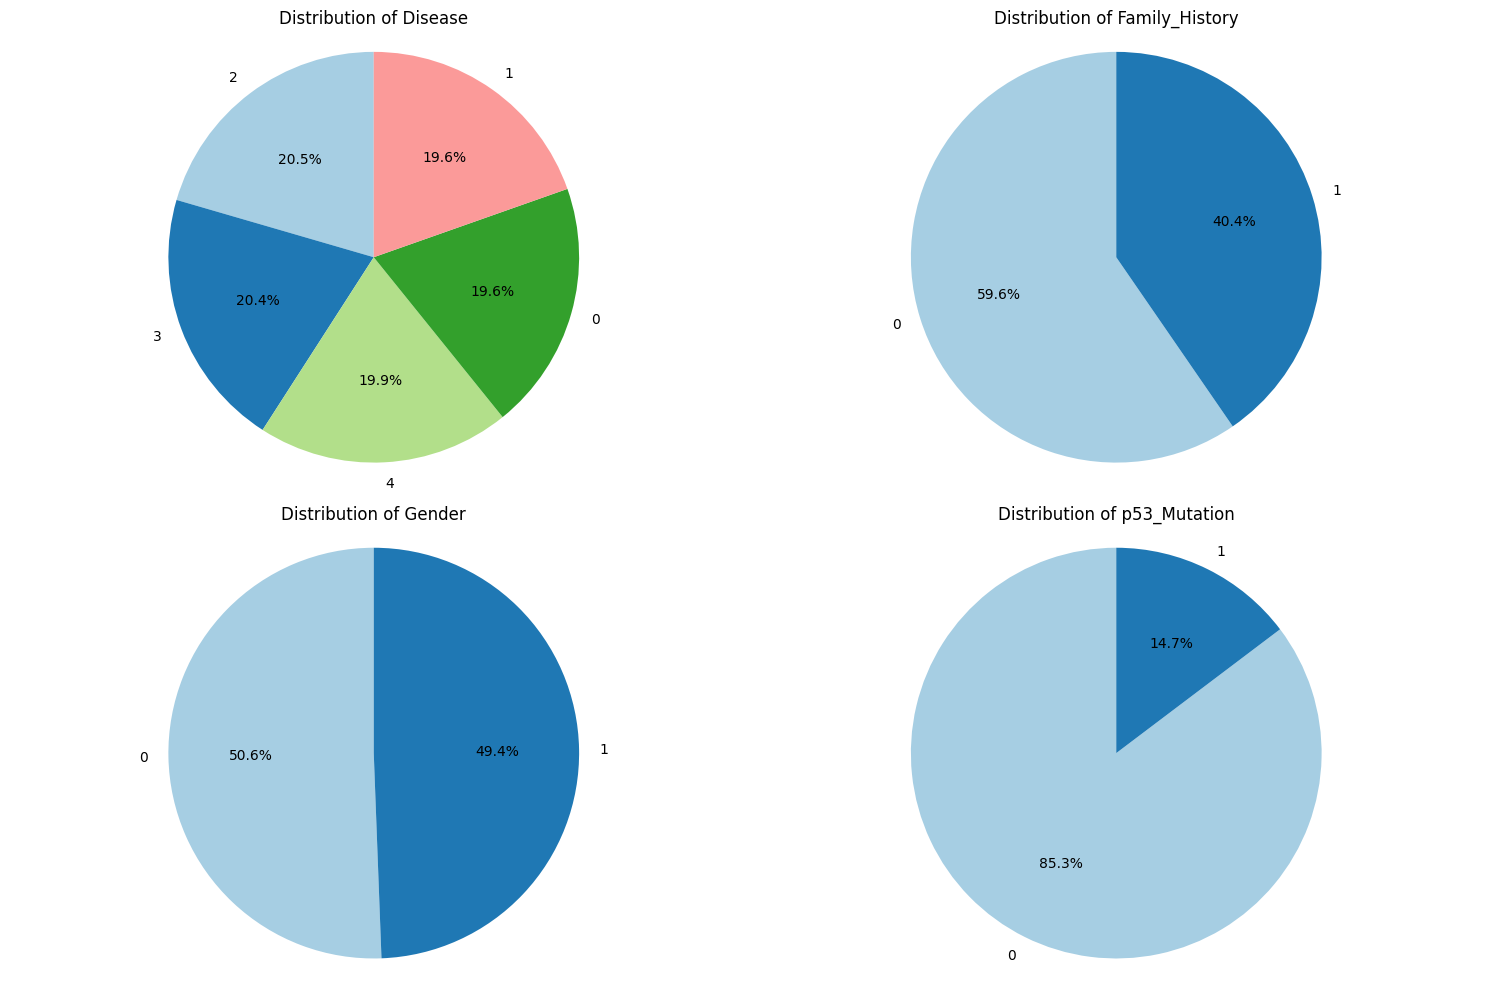

In [ ]:
import matplotlib.pyplot as plt

categorical_cols_for_pie = ['Disease', 'Family_History', 'Gender', 'p53_Mutation']

plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols_for_pie, 1):
    plt.subplot(2, 2, i)
    counts = df[col].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title(f'Distribution of {col}')
    plt.axis('equal')

plt.tight_layout()
plt.show()

**Interpretasi**

* **Disease**: Variabel target Disease terdiri dari lima kelas (0-4) dengan proporsi yang relatif seimbang. Kelas 2 memiliki persentase tertinggi yaitu 20,5%, sedangkan kelas 0 dan 1 masing-masing sebesar 19,6%. Hal ini menunjukkan bahwa dataset tidak mengalami class imbalance yang signifikan.
* **Family_History**: Sebanyak 59,6% responden tidak memiliki riwayat keluarga (kategori 0), sedangkan 40,4% responden memiliki riwayat keluarga (kategori 1). Distribusi ini menunjukkan bahwa mayoritas responden tidak memiliki riwayat penyakit dalam keluarga.
* **Gender**: Distribusi jenis kelamin relatif seimbang, dengan 50,6% pada kategori 0 dan 49,4% pada kategori 1. Kondisi ini menunjukkan bahwa tidak terdapat dominasi salah satu kategori gender dalam dataset.
* **p53_Mutation**: Sebagian besar responden (85,3%) berada pada kategori tidak mengalami mutasi p53 (0), sedangkan hanya 14,7% yang mengalami mutasi p53 (1). Hal ini menunjukkan bahwa kejadian mutasi p53 relatif lebih sedikit dibandingkan responden yang tidak mengalami mutasi.

Berdasarkan visualisasi distribusi, variabel Disease dan Gender memiliki distribusi yang relatif seimbang sehingga tidak menunjukkan indikasi ketidakseimbangan kelas. Sementara itu, variabel Family_History didominasi oleh kategori tidak memiliki riwayat keluarga, dan p53_Mutation menunjukkan distribusi yang tidak seimbang dengan mayoritas responden tidak mengalami mutasi p53.

##**Korelasi Antarvariabel**

###**Korelasi antarvariabel prediktor**

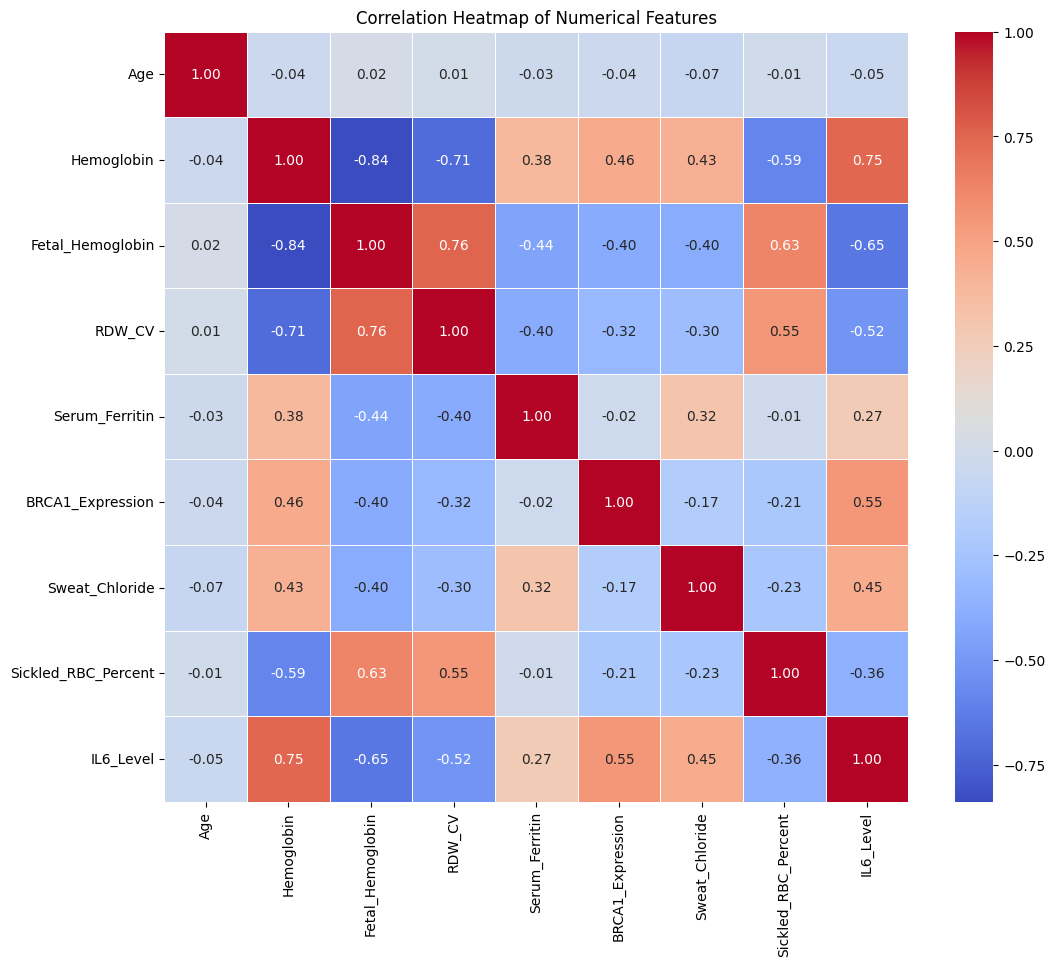

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the numerical columns
correlation_matrix = df[columns_to_plot].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Interpretasi**

Berdasarkan heatmap korelasi, sebagian besar variabel memiliki hubungan yang lemah hingga sedang. Korelasi negatif terkuat terdapat antara Hemoglobin dan Fetal_Hemoglobin dengan nilai -0,84, yang menunjukkan bahwa peningkatan kadar hemoglobin cenderung diikuti oleh penurunan kadar fetal hemoglobin. Selain itu, Hemoglobin juga memiliki korelasi negatif yang cukup kuat dengan RDW_CV (-0,71) serta korelasi positif yang kuat dengan IL6_Level (0,75).

Di sisi lain, korelasi positif terkuat ditemukan antara Fetal_Hemoglobin dan RDW_CV sebesar 0,76, yang menunjukkan bahwa kedua variabel cenderung meningkat secara bersamaan. Variabel Age memiliki nilai korelasi yang sangat rendah terhadap seluruh variabel lainnya (|r| < 0,10), sehingga menunjukkan bahwa usia tidak memiliki hubungan linear yang berarti dengan variabel-variabel biologis pada dataset.

###**Korelasi variabel prediktor dengan variabel target**

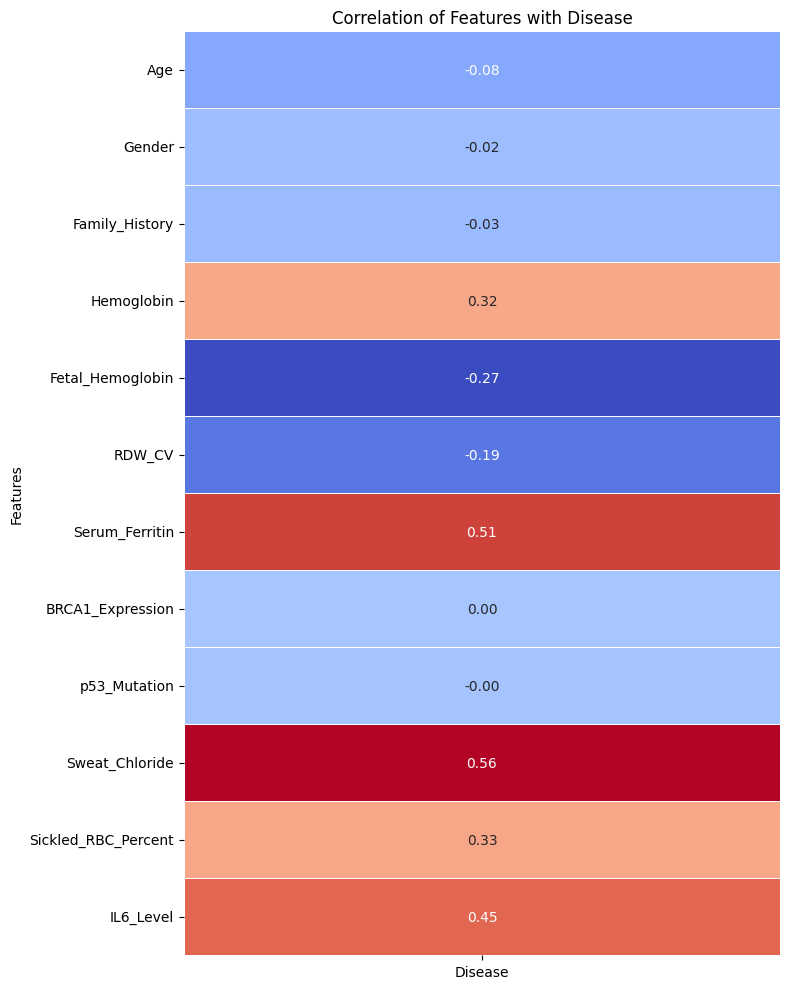

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Redefine X and y to ensure they are available in this cell's scope
X = df.drop(['Disease'], axis=1)
y = df['Disease']

# Combine X and y for correlation calculation
df_combined = pd.concat([X, y], axis=1)

# Calculate the correlation of all features with the target variable 'Disease'
correlation_with_target = df_combined.corr()['Disease'].drop('Disease')

# Plot the heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(correlation_with_target.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=False)
plt.title('Correlation of Features with Disease')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

**Interpretasi**

Berdasarkan heatmap korelasi terhadap variabel Disease, terdapat beberapa variabel yang memiliki hubungan lebih kuat dibandingkan variabel lainnya. Variabel Sweat_Chloride memiliki korelasi positif tertinggi (r = 0,56), diikuti oleh Serum_Ferritin (r = 0,51) dan IL6_Level (r = 0,45). Hal ini menunjukkan bahwa peningkatan nilai ketiga variabel tersebut cenderung diikuti dengan peningkatan kategori penyakit.

Sebaliknya, Fetal_Hemoglobin memiliki korelasi negatif terbesar terhadap Disease (r = -0,27), yang mengindikasikan bahwa semakin tinggi kadar fetal hemoglobin, kategori penyakit cenderung lebih rendah. Sementara itu, variabel Age, Gender, Family_History, BRCA1_Expression, dan p53_Mutation memiliki nilai korelasi yang sangat rendah (mendekati nol), sehingga menunjukkan hubungan linear yang lemah terhadap variabel target.

# **Preproccesing**

##**Mengecek Missing Value**

In [ ]:
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
Age                    0
Gender                 0
Family_History         0
Hemoglobin             0
Fetal_Hemoglobin       0
RDW_CV                 0
Serum_Ferritin         0
BRCA1_Expression       0
p53_Mutation           0
Sweat_Chloride         0
Sickled_RBC_Percent    0
IL6_Level              0
Disease                0
dtype: int64


**Interpretasi**

Tidak terdapat data yang hilang.

##**Mengecek Duplikat**

In [ ]:
print('Number of duplicate rows:')
print(df.duplicated().sum())

Number of duplicate rows:
0


**Interpretasi**

Tidak terdapat data duplikasi.

##**Menangani Outlier**

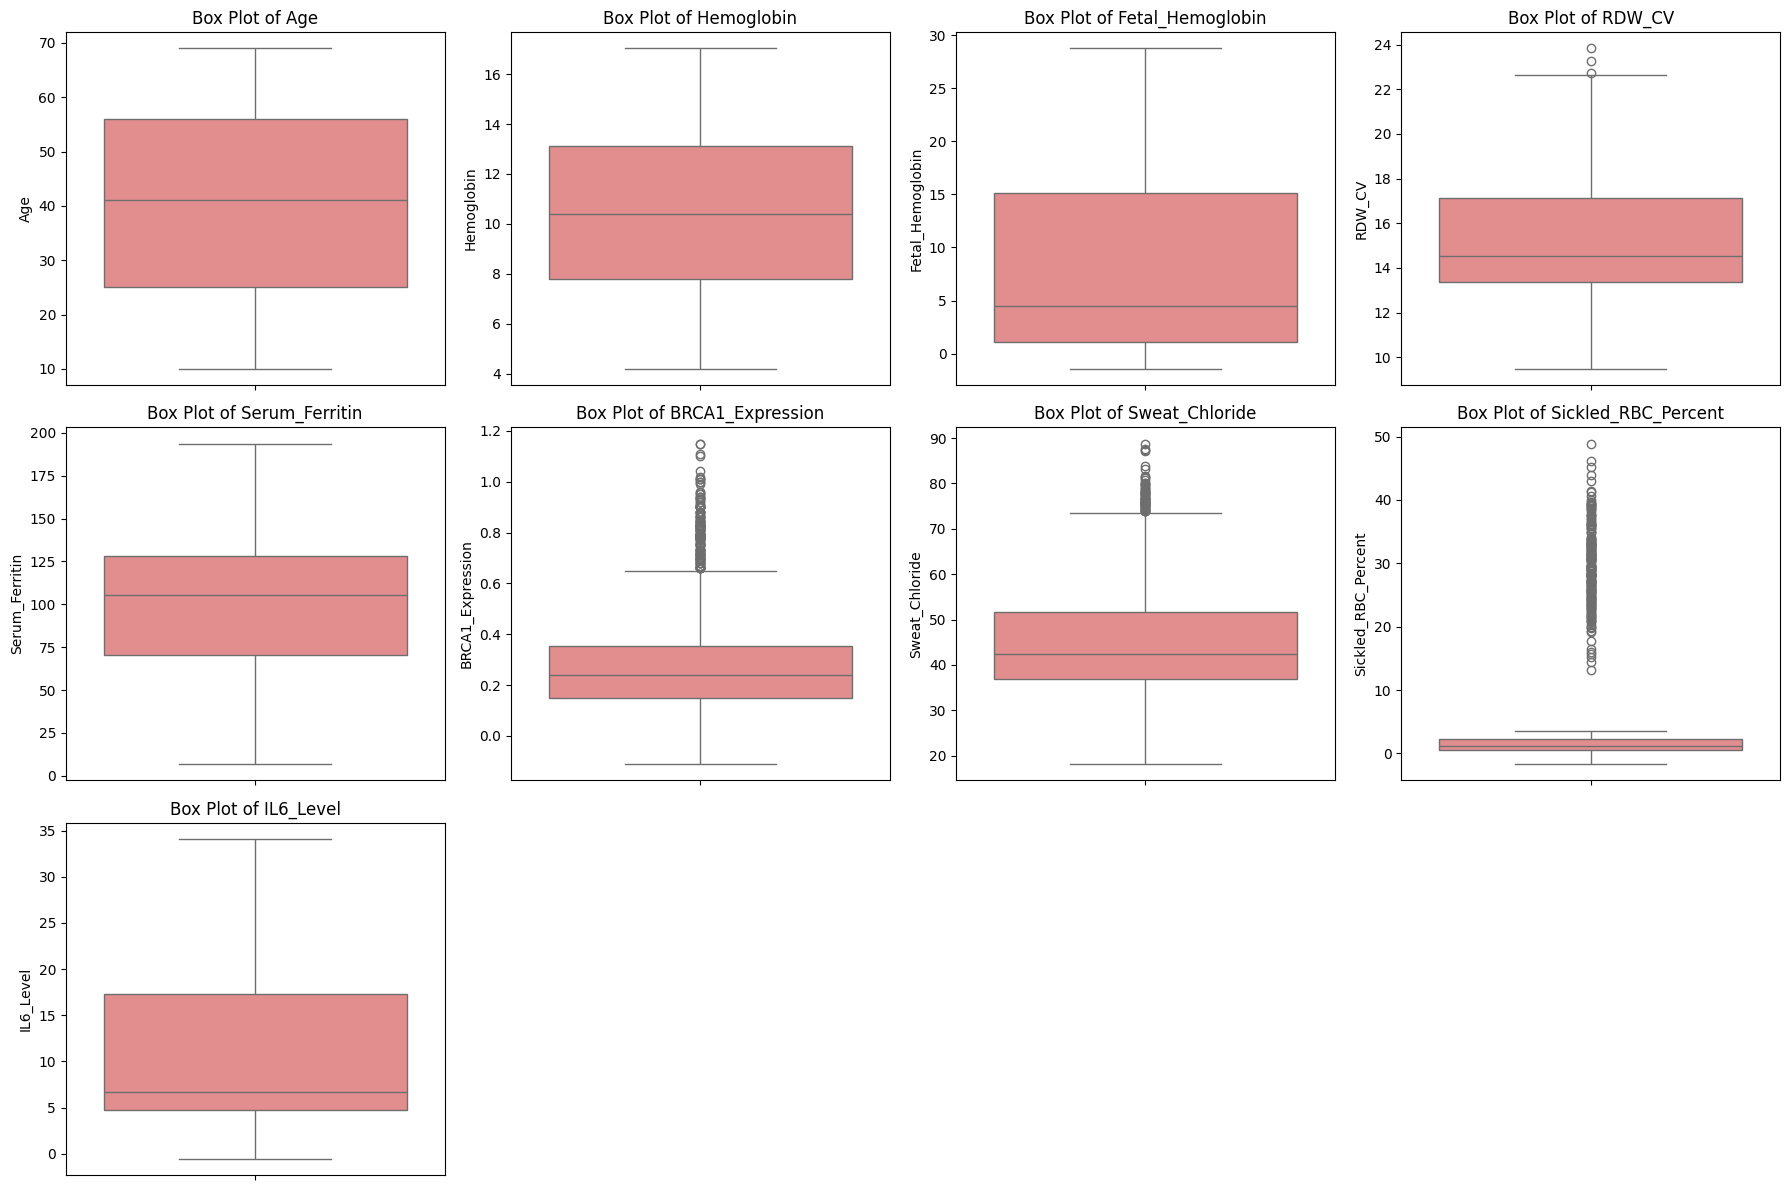

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize outliers using box plots for the numerical columns
plt.figure(figsize=(18, 12))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[column], color='lightcoral')
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

**Interpretasi**

Berdasarkan boxplot, variabel BRCA1_Expression, Sweat_Chloride, RDW_CV, dan terutama Sickled_RBC_Percent mengandung outlier yang cukup banyak. Sementara itu, variabel Age, Hemoglobin, Fetal_Hemoglobin, dan Serum_Ferritin cenderung memiliki distribusi yang lebih stabil tanpa outlier yang signifikan. Keberadaan outlier perlu diperhatikan pada tahap preprocessing karena dapat memengaruhi performa beberapa algoritma machine learning yang sensitif terhadap nilai ekstrem.

In [ ]:
# Apply the IQR method to cap outliers
for column in columns_to_plot:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers: values below lower_bound become lower_bound, values above upper_bound become upper_bound
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

print("Outliers have been capped using the IQR method for the following columns:")
print(columns_to_plot)

# Display descriptive statistics after capping outliers to observe changes
print("\nDescriptive statistics after outlier capping:")
display(df[columns_to_plot].describe())

Outliers have been capped using the IQR method for the following columns:
['Age', 'Hemoglobin', 'Fetal_Hemoglobin', 'RDW_CV', 'Serum_Ferritin', 'BRCA1_Expression', 'Sweat_Chloride', 'Sickled_RBC_Percent', 'IL6_Level']

Descriptive statistics after outlier capping:


,Age,Hemoglobin,Fetal_Hemoglobin,RDW_CV,Serum_Ferritin,BRCA1_Expression,Sweat_Chloride,Sickled_RBC_Percent,IL6_Level
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.075000,10.48321,7.952760,15.268710,99.648760,0.288860,46.283710,1.714920,10.515210
std,17.389991,2.96187,7.703486,2.480261,37.216059,0.198953,13.226512,1.620767,7.629332
min,10.000000,4.20000,-1.430000,9.480000,6.930000,-0.110000,18.160000,-1.660000,-0.590000
25%,25.000000,7.80000,1.100000,13.387500,70.507500,0.150000,36.912500,0.580000,4.677500
50%,41.000000,10.41000,4.510000,14.545000,105.390000,0.240000,42.495000,1.215000,6.650000
75%,56.000000,13.13250,15.120000,17.112500,128.122500,0.352500,51.637500,2.202500,17.287500
max,69.000000,17.03000,28.750000,22.700000,193.740000,0.656250,73.725000,4.636250,34.120000


**Interpretasi**

Berdasarkan statistik deskriptif setelah dilakukan penanganan outlier menggunakan metode Interquartile Range (IQR), seluruh variabel memiliki jumlah observasi sebanyak 1.000 data, yang menunjukkan bahwa proses penanganan outlier tidak mengurangi jumlah sampel yang dianalisis.

Nilai rata-rata dan median pada sebagian besar variabel, seperti Age (mean = 40,08; median = 41,00) dan Hemoglobin (mean = 10,48; median = 10,41), relatif berdekatan. Hal ini mengindikasikan bahwa distribusi data menjadi lebih seimbang dan tidak terlalu dipengaruhi oleh nilai ekstrem.

Pada variabel Fetal_Hemoglobin, Sickled_RBC_Percent, dan IL6_Level, rata-rata masih lebih besar dibandingkan median. Kondisi ini menunjukkan bahwa distribusi data masih sedikit menceng ke kanan (right-skewed), namun nilai maksimum yang diperoleh masih berada dalam rentang yang wajar setelah penanganan outlier sehingga tidak lagi memberikan pengaruh yang berlebihan terhadap ukuran pemusatan data.

Selain itu, standar deviasi seluruh variabel berada pada tingkat yang proporsional terhadap rentang datanya. Hal ini menunjukkan bahwa penyebaran data setelah penanganan outlier menjadi lebih terkendali dan mampu merepresentasikan karakteristik data secara lebih baik.

Secara keseluruhan, penanganan outlier menggunakan metode IQR berhasil mengurangi pengaruh nilai-nilai ekstrem sehingga distribusi data menjadi lebih stabil dan layak digunakan untuk analisis lanjutan, seperti pemodelan statistik maupun analisis inferensial.

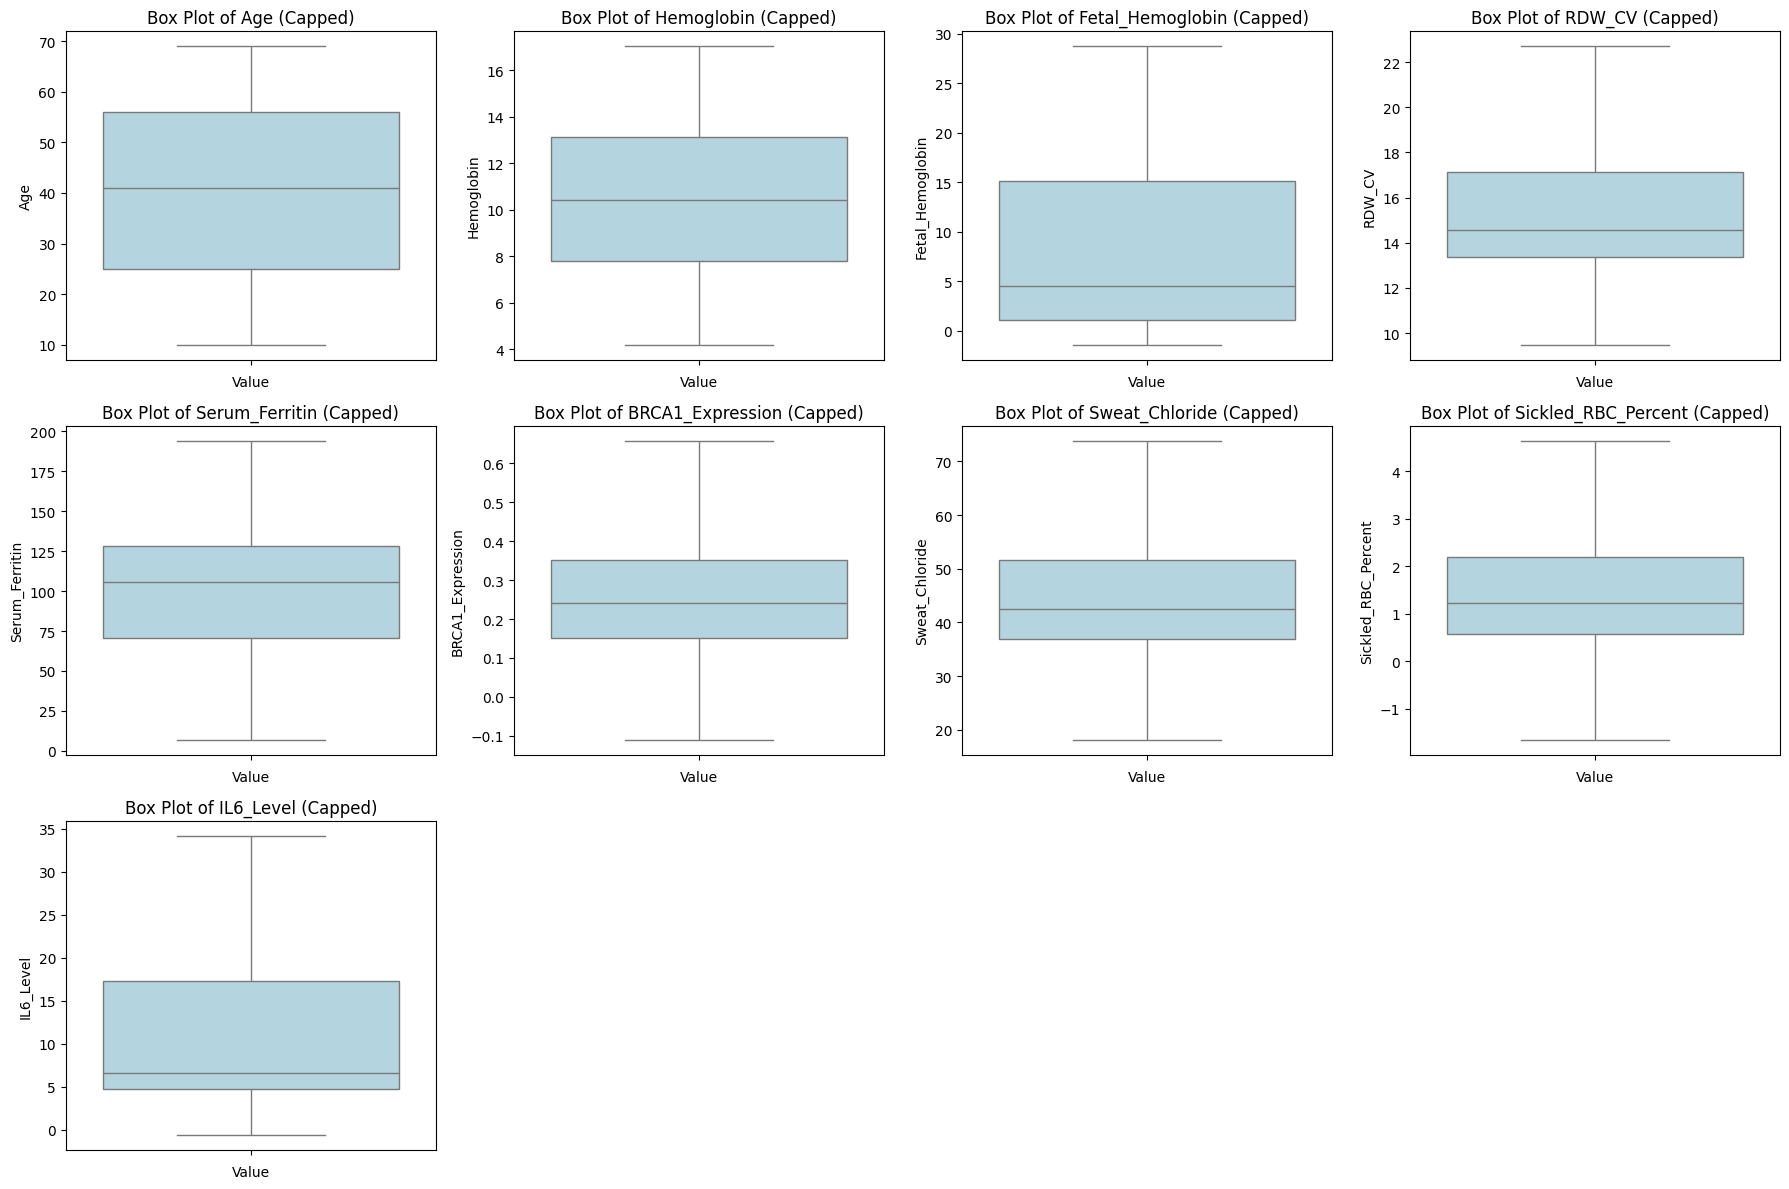

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize outliers using box plots for the numerical columns AFTER capping
plt.figure(figsize=(18, 12))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[column], color='lightblue') # Using a different color for clarity
    plt.title(f'Box Plot of {column} (Capped)')
    plt.xlabel('Value')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

**Interpretasi**

Outlier berhasil ditangani, terlihat dari boxplot sudah tidak ada titik-titik yang berada di luar box.

#**Konstruksi Data**

##**Standarisasi**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization to the numerical columns (columns_to_plot)
df[columns_to_plot] = scaler.fit_transform(df[columns_to_plot])

print("Numerical features standardized using StandardScaler.")
print("\nFirst 5 rows of the DataFrame after standardization:")
display(df.head())

Numerical features standardized using StandardScaler.

First 5 rows of the DataFrame after standardization:


,Age,Gender,Family_History,Hemoglobin,Fetal_Hemoglobin,RDW_CV,Serum_Ferritin,BRCA1_Expression,p53_Mutation,Sweat_Chloride,Sickled_RBC_Percent,IL6_Level,Disease
0,0.455950,1,1,-1.027976,0.673700,-0.644896,-1.237148,0.357751,0,-0.069116,-0.675895,-0.580316,0
1,0.743616,0,0,-1.058378,0.972415,1.202608,-1.798746,0.307462,0,-0.594839,-0.410455,-1.097002,3
2,0.455950,1,1,-0.754364,-0.102961,1.057389,-1.870256,-0.446862,0,-1.035084,-0.033902,-1.043236,0
3,-0.752245,1,0,-0.653026,0.959427,1.480944,-1.943648,-0.044555,0,0.930891,-0.311687,-0.293122,0
4,-0.119381,0,0,-0.571955,1.039951,1.839956,-1.402482,0.005733,0,-0.116772,-0.095632,-0.677359,0


**Interpretasi**

Berdasarkan output di atas, seluruh variabel numerik telah berhasil distandardisasi menggunakan StandardScaler. Hasil standardisasi ditunjukkan oleh nilai data yang berpusat di sekitar 0 dengan skala yang seragam. Nilai positif menunjukkan observasi berada di atas rata-rata, sedangkan nilai negatif menunjukkan observasi berada di bawah rata-rata. Proses standardisasi ini dilakukan untuk menyamakan skala antarvariabel sehingga tidak ada variabel dengan rentang nilai yang lebih besar mendominasi proses analisis atau pemodelan selanjutnya.

##**Feature Selection**

In [ ]:
X=df.drop(['Disease'], axis=1)
y=df['Disease']

**Interpretasi**

Dataset dipisahkan menjadi dua bagian, yaitu:
X berisi seluruh variabel prediktor (fitur) yang akan digunakan sebagai input model, yaitu sebanyak 12 variabel independen.
y berisi variabel target, yaitu Disease, yang akan diprediksi oleh model.
Pemisahan ini dilakukan agar model machine learning dapat mempelajari hubungan antara variabel-variabel prediktor dengan status Disease.

##**Split Dataset**

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)
print ('Ukuran X_train : ', X_train.shape)
print ('Ukuran X_test  : ', X_test.shape)
print ('Ukuran y_train : ', y_train.shape)
print ('Ukuran y_test  : ', y_test.shape)

Ukuran X_train :  (800, 12)
Ukuran X_test  :  (200, 12)
Ukuran y_train :  (800,)
Ukuran y_test  :  (200,)


**Interpretasi**

Dataset dibagi menjadi data latih (training set) dan data uji (testing set) dengan proporsi 80:20. Dari total 1.000 observasi, sebanyak 800 data (80%) digunakan untuk melatih model dan 200 data (20%) digunakan untuk menguji kinerja model. Baik data latih maupun data uji memiliki 12 variabel prediktor, sedangkan variabel target masing-masing terdiri atas 800 dan 200 observasi. Parameter random_state=42 digunakan agar proses pembagian data bersifat tetap (reproducible) sehingga hasil yang diperoleh dapat direplikasi pada proses analisis berikutnya.

##**Feature Importance**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan latih model Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Dapatkan skor Feature Importance
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Tampilkan skor Feature Importance
print("Skor Feature Importance terhadap Disease:")
print(feature_importances)

Skor Feature Importance terhadap Disease:
Sickled_RBC_Percent    0.173700
Fetal_Hemoglobin       0.137285
Sweat_Chloride         0.135226
BRCA1_Expression       0.130133
IL6_Level              0.126170
Serum_Ferritin         0.119014
Hemoglobin             0.076116
RDW_CV                 0.056189
p53_Mutation           0.029320
Age                    0.011607
Gender                 0.002728
Family_History         0.002512
dtype: float64


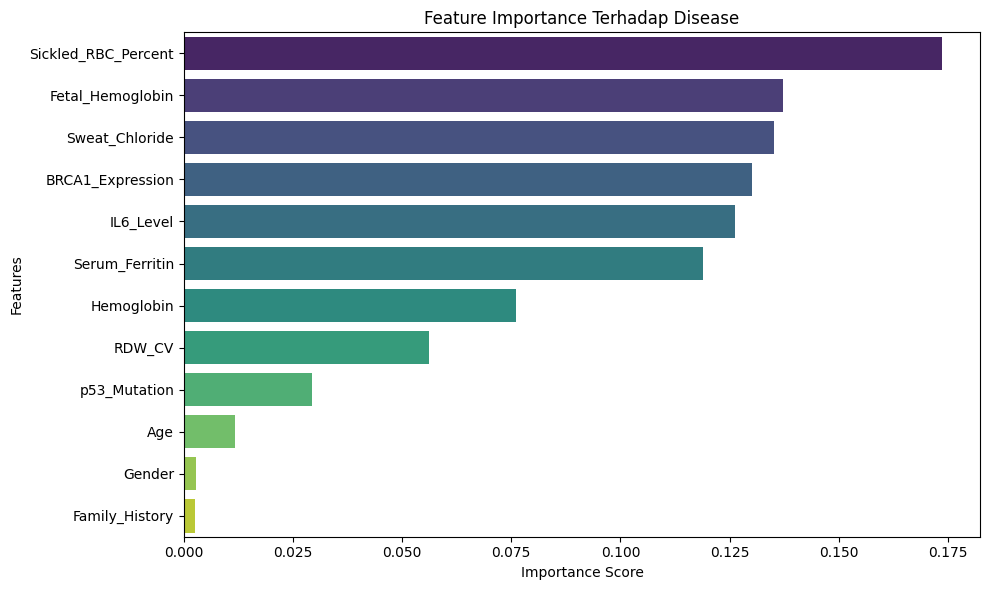

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis', hue=feature_importances.index, legend=False)
plt.title('Feature Importance Terhadap Disease')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

**Interpretasi**

Berdasarkan hasil feature importance, variabel yang memiliki kontribusi paling besar dalam memprediksi Disease adalah Sickled_RBC_Percent dengan skor importance sebesar 0,1737. Hal ini menunjukkan bahwa persentase sel darah merah berbentuk sabit merupakan faktor yang paling berpengaruh dalam membedakan kondisi penyakit pada dataset.

Variabel lain yang juga memiliki pengaruh cukup besar adalah Fetal_Hemoglobin (0,1373), Sweat_Chloride (0,1352), BRCA1_Expression (0,1301), IL6_Level (0,1262), dan Serum_Ferritin (0,1190). Keenam variabel tersebut memiliki nilai importance yang relatif tinggi, sehingga dapat dianggap sebagai prediktor utama dalam proses klasifikasi penyakit.

Selanjutnya, Hemoglobin (0,0761) dan RDW_CV (0,0562) memberikan kontribusi sedang terhadap prediksi penyakit. Sementara itu, p53_Mutation (0,0293) dan Age (0,0116) memiliki pengaruh yang relatif kecil.

Adapun Gender (0,0027) dan Family_History (0,0025) merupakan variabel dengan nilai importance terendah, sehingga kontribusinya terhadap prediksi Disease pada dataset ini sangat kecil dibandingkan variabel lainnya.

Secara keseluruhan, hasil feature importance menunjukkan bahwa prediksi Disease lebih banyak dipengaruhi oleh variabel yang berkaitan dengan kondisi hematologis dan biomarker biologis, terutama Sickled_RBC_Percent, Fetal_Hemoglobin, Sweat_Chloride, BRCA1_Expression, IL6_Level, dan Serum_Ferritin.

In [ ]:
!pip install shap

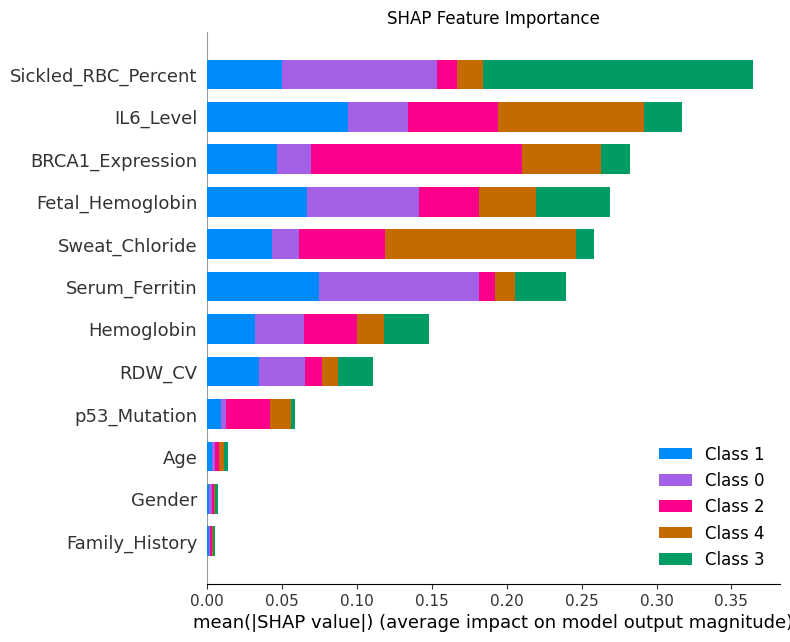

In [ ]:
import shap

# Create a SHAP explainer object
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the training data
shap_values = explainer.shap_values(X_train)

# Plot the SHAP summary plot
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title('SHAP Feature Importance')
plt.show()

**Interpretasi**

Berdasarkan grafik SHAP Feature Importance (mean(|SHAP value|)), variabel diurutkan berdasarkan rata-rata besarnya kontribusi terhadap prediksi model pada seluruh data. Semakin besar nilai mean(|SHAP value|), semakin besar pengaruh variabel tersebut dalam menentukan kelas penyakit.

Variabel dengan pengaruh terbesar adalah Sickled_RBC_Percent, diikuti oleh IL6_Level, BRCA1_Expression, Fetal_Hemoglobin, Sweat_Chloride, dan Serum_Ferritin. Hal ini menunjukkan bahwa model lebih banyak mempertimbangkan biomarker hematologis dan biologis tersebut dalam proses klasifikasi penyakit.

Sebaliknya, Hemoglobin dan RDW_CV memiliki pengaruh yang relatif sedang, sedangkan p53_Mutation, Age, Gender, dan Family_History memiliki nilai mean(|SHAP value|) yang kecil sehingga kontribusinya terhadap prediksi model relatif rendah.

Selain itu, batang berwarna menunjukkan kontribusi masing-masing variabel terhadap setiap kelas penyakit (Class 0, Class 1, Class 2, Class 3, dan Class 4). Misalnya, Sickled_RBC_Percent memberikan kontribusi yang cukup besar terutama pada Class 3, sedangkan IL6_Level dan BRCA1_Expression memiliki kontribusi yang lebih tersebar pada beberapa kelas.

In [ ]:
import shap
import matplotlib.pyplot as plt

instance_to_explain = X_test.iloc[0]
shap_values_all_classes = explainer.shap_values(instance_to_explain)
shap_values_for_class_0 = shap_values_all_classes[:, 0]

instance_values = instance_to_explain.values

feature_names = X_test.columns.tolist()

shap.initjs()

expected_value_class_0 = explainer.expected_value[0]

print(f"Local SHAP explanation for the first instance in X_test (class 0):")
shap.force_plot(expected_value_class_0, shap_values_for_class_0, instance_values, feature_names=feature_names)


Local SHAP explanation for the first instance in X_test (class 0):


**Interpretasi**

Grafik Local SHAP Explanation menjelaskan prediksi model untuk satu observasi pertama pada data uji (instance pertama pada X_test). Nilai prediksi akhir model ditunjukkan oleh f(x), sedangkan base value merupakan nilai prediksi rata-rata model sebelum mempertimbangkan karakteristik observasi tersebut.

Pada grafik, warna:

* Biru menunjukkan variabel yang meningkatkan nilai prediksi menuju kelas yang diprediksi.
* Merah menunjukkan variabel yang menurunkan nilai prediksi.

Untuk observasi ini, variabel IL6_Level = 2,021, BRCA1_Expression = 1,848, Hemoglobin = 1,134, Fetal_Hemoglobin = -0,8277, Serum_Ferritin = -0,3992, dan RDW_CV = -0,6409 memberikan kontribusi positif (biru) dan mendorong prediksi model ke arah kelas yang diprediksi. Sementara itu, Sickled_RBC_Percent = 0,01548 memberikan kontribusi negatif (merah) sehingga sedikit mengurangi kecenderungan model menuju kelas tersebut.

Secara keseluruhan, prediksi pada observasi pertama lebih banyak dipengaruhi oleh kontribusi positif dari IL6_Level, BRCA1_Expression, dan Hemoglobin, sehingga nilai prediksi akhir model bergeser dari base value menuju kelas yang diprediksi oleh model.

# **Pemodelan**

##**Model Awal**

###**XG Boost**

Training XGBoost Classifier...
XGBoost Classifier training complete.

--- XGBoost Classifier Model Evaluation ---
Accuracy: 0.9300

Confusion Matrix:


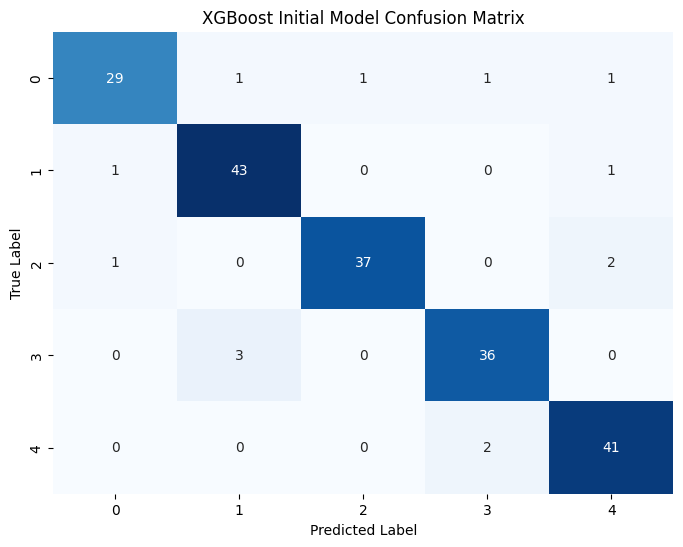


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.91      0.96      0.93        45
           2       0.97      0.93      0.95        40
           3       0.92      0.92      0.92        39
           4       0.91      0.95      0.93        43

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200

ROC AUC (Macro Avg): 0.9715


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

model_xgb = XGBClassifier(random_state=42)

print("Training XGBoost Classifier...")
model_xgb.fit(X_train, y_train)
print("XGBoost Classifier training complete.")


y_pred_xgb = model_xgb.predict(X_test)
y_pred_proba_xgb = model_xgb.predict_proba(X_test)

# Evaluate the model
print("\n--- XGBoost Classifier Model Evaluation ---")

# Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy: {accuracy_xgb:.4f}")

# Confusion Matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
# print(conf_matrix_xgb) # Original print statement, now replaced by heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=model_xgb.classes_, yticklabels=model_xgb.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Initial Model Confusion Matrix')
plt.show()

# Classification Report
class_report_xgb = classification_report(y_test, y_pred_xgb)
print("\nClassification Report:")
print(class_report_xgb)

# ROC AUC Score (One-vs-Rest for multi-class)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb, multi_class='ovr', average='macro')
print(f"ROC AUC (Macro Avg): {roc_auc_xgb:.4f}")

**Interpretasi Model Awal: XGBoost Classifier**

**Confusion Matrix:**
```
[[29  1  1  1  1]
 [ 1 43  0  0  1]
 [ 1  0 37  0  2]
 [ 0  3  0 36  0]
 [ 0  0  0  2 41]]
```
*   **Prediksi Benar (Diagonal)**:
    *   Kelas 0: 29 diprediksi benar (dari 33 total aktual)
    *   Kelas 1: 43 diprediksi benar (dari 45 total aktual)
    *   Kelas 2: 37 diprediksi benar (dari 40 total aktual)
    *   Kelas 3: 36 diprediksi benar (dari 39 total aktual)
    *   Kelas 4: 41 diprediksi benar (dari 43 total aktual)
*   **Prediksi Salah (Non-Diagonal)**:
    *   Kelas 0 aktual salah diprediksi sebagai Kelas 1 (1), Kelas 2 (1), Kelas 3 (1), Kelas 4 (1).
    *   Kelas 1 aktual salah diprediksi sebagai Kelas 0 (1), Kelas 4 (1).
    *   Kelas 2 aktual salah diprediksi sebagai Kelas 0 (1), Kelas 4 (2).
    *   Kelas 3 aktual salah diprediksi sebagai Kelas 1 (3).
    *   Kelas 4 aktual salah diprediksi sebagai Kelas 3 (2).

**Classification Report:**
*   **Accuracy: 0.9300**
    *   Model secara keseluruhan memprediksi dengan benar 93% dari semua observasi.
*   **Precision (Macro Avg): 0.93**
    *   Rata-rata kemampuan model untuk memprediksi kelas positif dengan benar (minimalkan *false positives*) adalah 93%.
*   **Recall (Macro Avg): 0.93**
    *   Rata-rata kemampuan model untuk menemukan semua instance positif yang sebenarnya (minimalkan *false negatives*) adalah 93%.
*   **F1-Score (Macro Avg): 0.93**
    *   Rata-rata harmonik dari presisi dan recall adalah 93%, menunjukkan keseimbangan yang baik antara kedua metrik ini.
*   **ROC AUC (Macro Avg): 0.9715**
    *   Nilai ROC AUC sebesar 0.9715 menunjukkan bahwa model XGBoost awal memiliki kemampuan diskriminatif yang sangat baik dalam membedakan antara kelas-kelas penyakit. Semakin tinggi nilai ROC AUC mendekati 1, semakin baik model dalam mengklasifikasikan kelas positif dan negatif.

Secara ringkas, model XGBoost awal menunjukkan performa yang baik dengan akurasi 93%. Model ini cukup seimbang dalam memprediksi setiap kelas, meskipun ada beberapa kesalahan klasifikasi antar kelas, terutama terlihat pada Kelas 0 dan Kelas 3 yang memiliki beberapa *false negatives* dan *false positives*.

###**SVM Kernel Linear**

Training SVM Classifier...
SVM Classifier training complete.

--- SVM Classifier Model Evaluation ---
Accuracy: 0.9500

Confusion Matrix:


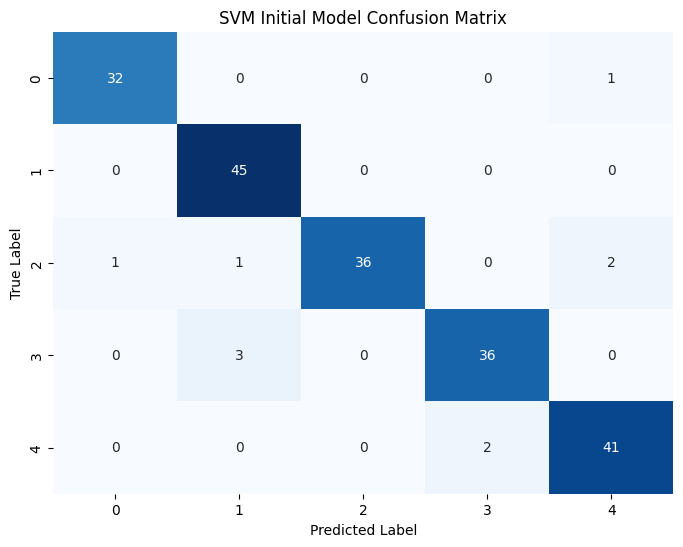


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.92      1.00      0.96        45
           2       1.00      0.90      0.95        40
           3       0.95      0.92      0.94        39
           4       0.93      0.95      0.94        43

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200

ROC AUC (Macro Avg): 0.9725


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set probability=True to enable predict_proba for ROC AUC calculation
model_svm = SVC(kernel='linear', random_state=42, probability=True)

# Train the model
print("Training SVM Classifier...")
model_svm.fit(X_train, y_train)
print("SVM Classifier training complete.")

# Make predictions on the test set
y_pred_svm = model_svm.predict(X_test)
y_pred_proba_svm = model_svm.predict_proba(X_test)

# Evaluate the model
print("\n--- SVM Classifier Model Evaluation ---")

# Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svm:.4f}")

# Confusion Matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:")
# print(conf_matrix_svm) # Original print statement, now replaced by heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=model_svm.classes_, yticklabels=model_svm.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Initial Model Confusion Matrix')
plt.show()

# Classification Report
class_report_svm = classification_report(y_test, y_pred_svm)
print("\nClassification Report:")
print(class_report_svm)

# ROC AUC Score (One-vs-Rest for multi-class)
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm, multi_class='ovr', average='macro')
print(f"ROC AUC (Macro Avg): {roc_auc_svm:.4f}")

**Interpretasi Model Awal: SVM Classifier**

**Confusion Matrix:**
```
[[32  0  0  0  1]
 [ 0 45  0  0  0]
 [ 1  1 36  0  2]
 [ 0  3  0 36  0]
 [ 0  0  0  2 41]]
```
*   **Prediksi Benar (Diagonal)**:
    *   Kelas 0: 32 diprediksi benar (dari 33 total aktual)
    *   Kelas 1: 45 diprediksi benar (dari 45 total aktual) - Sempurna!
    *   Kelas 2: 36 diprediksi benar (dari 40 total aktual)
    *   Kelas 3: 36 diprediksi benar (dari 39 total aktual)
    *   Kelas 4: 41 diprediksi benar (dari 43 total aktual)
*   **Prediksi Salah (Non-Diagonal)**:
    *   Kelas 0 aktual salah diprediksi sebagai Kelas 4 (1).
    *   Kelas 1 aktual tidak ada kesalahan.
    *   Kelas 2 aktual salah diprediksi sebagai Kelas 0 (1), Kelas 1 (1), Kelas 4 (2).
    *   Kelas 3 aktual salah diprediksi sebagai Kelas 1 (3).
    *   Kelas 4 aktual salah diprediksi sebagai Kelas 3 (2).

**Classification Report:**
*   **Accuracy: 0.9500**
    *   Model SVM menunjukkan akurasi yang sangat baik, yaitu 95% prediksi benar secara keseluruhan.
*   **Precision (Macro Avg): 0.95**
    *   Rata-rata presisi sebesar 95%, menunjukkan model cukup handal dalam memprediksi kelas positif.
*   **Recall (Macro Avg): 0.95**
    *   Rata-rata recall sebesar 95%, menandakan model efektif dalam menangkap sebagian besar instance positif.
*   **F1-Score (Macro Avg): 0.95**
    *   F1-Score rata-rata 95%, menunjukkan keseimbangan yang kuat antara presisi dan recall.
*   **ROC AUC (Macro Avg): 0.9725**
    *   Dengan ROC AUC sebesar 0.9725, model SVM awal juga menunjukkan kemampuan diskriminatif yang luar biasa, sedikit lebih tinggi dari XGBoost awal, dalam membedakan kelas-kelas penyakit.

Model SVM awal menunjukkan performa yang sangat kuat, bahkan lebih baik dari XGBoost awal, dengan akurasi 95%. Khususnya, model ini sangat baik dalam memprediksi Kelas 1 tanpa kesalahan sama sekali. Kesalahan terbesar cenderung terjadi pada Kelas 2 dan Kelas 3 yang masih memiliki beberapa *false positives* atau *false negatives*.

###**Random Forest**

Training Random Forest Classifier...
Random Forest Classifier training complete.

--- Random Forest Classifier Model Evaluation ---
Accuracy: 0.9550

Confusion Matrix:


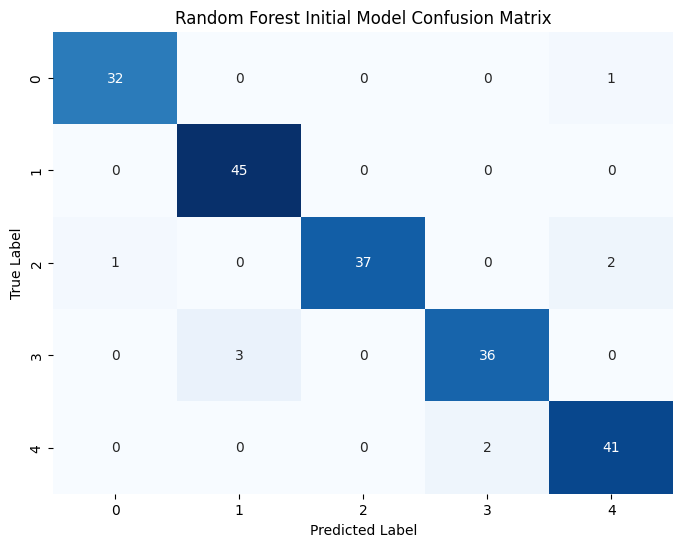


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.94      1.00      0.97        45
           2       1.00      0.93      0.96        40
           3       0.95      0.92      0.94        39
           4       0.93      0.95      0.94        43

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.96       200
weighted avg       0.96      0.95      0.95       200

ROC AUC (Macro Avg): 0.9722


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

model_rf = RandomForestClassifier(random_state=42)

# Train the model
print("Training Random Forest Classifier...")
model_rf.fit(X_train, y_train)
print("Random Forest Classifier training complete.")

# Make predictions on the test set
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)

# Evaluate the model
print("\n--- Random Forest Classifier Model Evaluation ---")

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
# print(conf_matrix_rf) # Original print statement, now replaced by heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=model_rf.classes_, yticklabels=model_rf.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Initial Model Confusion Matrix')
plt.show()

# Classification Report
class_report_rf = classification_report(y_test, y_pred_rf)
print("\nClassification Report:")
print(class_report_rf)

# ROC AUC Score (One-vs-Rest for multi-class)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr', average='macro')
print(f"ROC AUC (Macro Avg): {roc_auc_rf:.4f}")

**Interpretasi Model Awal: Random Forest Classifier**

**Confusion Matrix:**
```
[[32  0  0  0  1]
 [ 0 45  0  0  0]
 [ 1  0 37  0  2]
 [ 0  3  0 36  0]
 [ 0  0  0  2 41]]
```
*   **Prediksi Benar (Diagonal)**:
    *   Kelas 0: 32 diprediksi benar (dari 33 total aktual)
    *   Kelas 1: 45 diprediksi benar (dari 45 total aktual) - Sempurna!
    *   Kelas 2: 37 diprediksi benar (dari 40 total aktual)
    *   Kelas 3: 36 diprediksi benar (dari 39 total aktual)
    *   Kelas 4: 41 diprediksi benar (dari 43 total aktual)
*   **Prediksi Salah (Non-Diagonal)**:
    *   Kelas 0 aktual salah diprediksi sebagai Kelas 4 (1).
    *   Kelas 1 aktual tidak ada kesalahan.
    *   Kelas 2 aktual salah diprediksi sebagai Kelas 0 (1), Kelas 4 (2).
    *   Kelas 3 aktual salah diprediksi sebagai Kelas 1 (3).
    *   Kelas 4 aktual salah diprediksi sebagai Kelas 3 (2).

**Classification Report:**
*   **Accuracy: 0.9550**
    *   Model Random Forest mencapai akurasi tertinggi di antara model awal, yaitu 95.5%.
*   **Precision (Macro Avg): 0.96**
    *   Rata-rata presisi yang sangat tinggi (96%), menunjukkan keandalan model dalam prediksi positif.
*   **Recall (Macro Avg): 0.95**
    *   Rata-rata recall 95%, yang berarti model sangat baik dalam mengidentifikasi sebagian besar kasus positif.
*   **F1-Score (Macro Avg): 0.96**
    *   F1-Score rata-rata 96%, mengkonfirmasi performa yang superior dengan keseimbangan presisi dan recall yang sangat baik.
*   **ROC AUC (Macro Avg): 0.9722**
    *   Model Random Forest awal memiliki ROC AUC sebesar 0.9722, yang mengindikasikan kemampuan diskriminatif yang sangat kuat, sebanding dengan SVM awal, dalam membedakan berbagai kategori penyakit.

Random Forest Classifier menunjukkan performa awal terbaik dengan akurasi 95.5%. Seperti SVM, model ini juga sempurna dalam memprediksi Kelas 1. Pola kesalahan prediksinya mirip dengan SVM, dengan beberapa misklasifikasi pada Kelas 0, 2, 3, dan 4, namun secara keseluruhan sangat minim.

##**Model Hyperparameter Tuning**

###**Random Forest Tuning**

Starting GridSearchCV for Random Forest Classifier...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
GridSearchCV complete.

Best parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation accuracy: 0.9563

--- Tuned Random Forest Classifier Model Evaluation ---
Accuracy: 0.9500

Confusion Matrix:


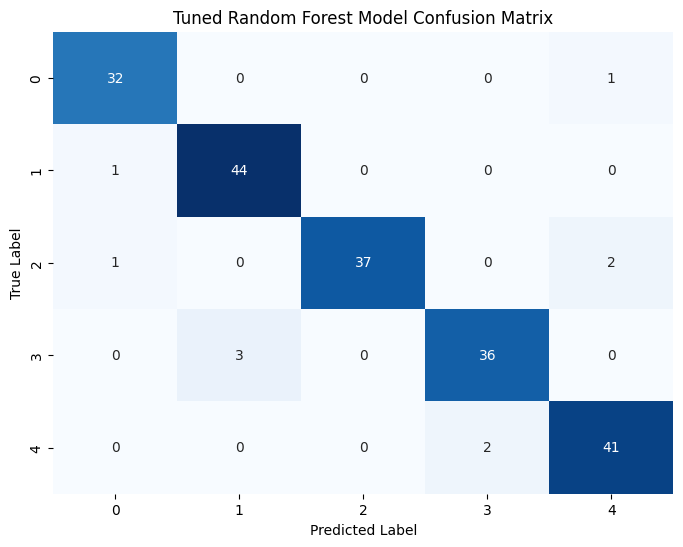


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        33
           1       0.94      0.98      0.96        45
           2       1.00      0.93      0.96        40
           3       0.95      0.92      0.94        39
           4       0.93      0.95      0.94        43

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200

ROC AUC (Macro Avg): 0.9733


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available cores
    scoring='accuracy', # Optimize for accuracy
    verbose=1
)

print("Starting GridSearchCV for Random Forest Classifier...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("GridSearchCV complete.")

# Get the best parameters and best score
best_params_rf = grid_search.best_params_
best_score_rf = grid_search.best_score_

print(f"\nBest parameters found: {best_params_rf}")
print(f"Best cross-validation accuracy: {best_score_rf:.4f}")

# Get the best model
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_pred_proba_rf_tuned = best_rf_model.predict_proba(X_test)

# Evaluate the best model
print("\n--- Tuned Random Forest Classifier Model Evaluation ---")

# Accuracy
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
print(f"Accuracy: {accuracy_rf_tuned:.4f}")

# Confusion Matrix
conf_matrix_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
print("\nConfusion Matrix:")
# print(conf_matrix_rf_tuned) # Original print statement, now replaced by heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=best_rf_model.classes_, yticklabels=best_rf_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Tuned Random Forest Model Confusion Matrix')
plt.show()

# Classification Report
class_report_rf_tuned = classification_report(y_test, y_pred_rf_tuned)
print("\nClassification Report:")
print(class_report_rf_tuned)

# ROC AUC Score (One-vs-Rest for multi-class)
roc_auc_rf_tuned = roc_auc_score(y_test, y_pred_proba_rf_tuned, multi_class='ovr', average='macro')
print(f"ROC AUC (Macro Avg): {roc_auc_rf_tuned:.4f}")

**Interpretasi Model Tuning: Random Forest Classifier**

**Confusion Matrix:**
```
[[32  0  0  0  1]
 [ 1 44  0  0  0]
 [ 1  0 37  0  2]
 [ 0  3  0 36  0]
 [ 0  0  0  2 41]]
```
*   **Prediksi Benar (Diagonal)**:
    *   Kelas 0: 32 diprediksi benar (dari 33 total aktual)
    *   Kelas 1: 44 diprediksi benar (dari 45 total aktual)
    *   Kelas 2: 37 diprediksi benar (dari 40 total aktual)
    *   Kelas 3: 36 diprediksi benar (dari 39 total aktual)
    *   Kelas 4: 41 diprediksi benar (dari 43 total aktual)
*   **Prediksi Salah (Non-Diagonal)**:
    *   Kelas 0 aktual salah diprediksi sebagai Kelas 4 (1).
    *   Kelas 1 aktual salah diprediksi sebagai Kelas 0 (1).
    *   Kelas 2 aktual salah diprediksi sebagai Kelas 0 (1), Kelas 4 (2).
    *   Kelas 3 aktual salah diprediksi sebagai Kelas 1 (3).
    *   Kelas 4 aktual salah diprediksi sebagai Kelas 3 (2).

**Classification Report:**
*   **Accuracy: 0.9500**
    *   Akurasi sedikit menurun menjadi 95.00% dari 95.50% pada model awal, namun masih sangat tinggi.
*   **Precision (Macro Avg): 0.95**
    *   Rata-rata presisi tetap tinggi di 95%.
*   **Recall (Macro Avg): 0.95**
    *   Rata-rata recall tetap di 95%.
*   **F1-Score (Macro Avg): 0.95**
    *   Rata-rata F1-Score tetap tinggi di 95%.
*   **ROC AUC (Macro Avg): 0.9733**
    *   Setelah *tuning*, ROC AUC model Random Forest meningkat sedikit menjadi 0.9733, menegaskan bahwa *tuning* berhasil mempertahankan dan sedikit meningkatkan kemampuan diskriminatif model secara keseluruhan.

Setelah *tuning*, Random Forest menunjukkan sedikit penurunan pada akurasi keseluruhan, tetapi metrik lain seperti presisi, recall, dan F1-Score tetap sangat kuat (0.95-0.96). Perubahan pada *confusion matrix* menunjukkan sedikit pergeseran kesalahan, misalnya kini ada 1 *false negative* untuk Kelas 1 yang sebelumnya sempurna. Namun, model ini secara keseluruhan tetap sangat performatif dan stabil.

###**SVM Tuning**

Starting GridSearchCV for SVM Classifier...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
GridSearchCV complete.

Best parameters found: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9550

--- Tuned SVM Classifier Model Evaluation ---
Accuracy: 0.9550

Confusion Matrix:


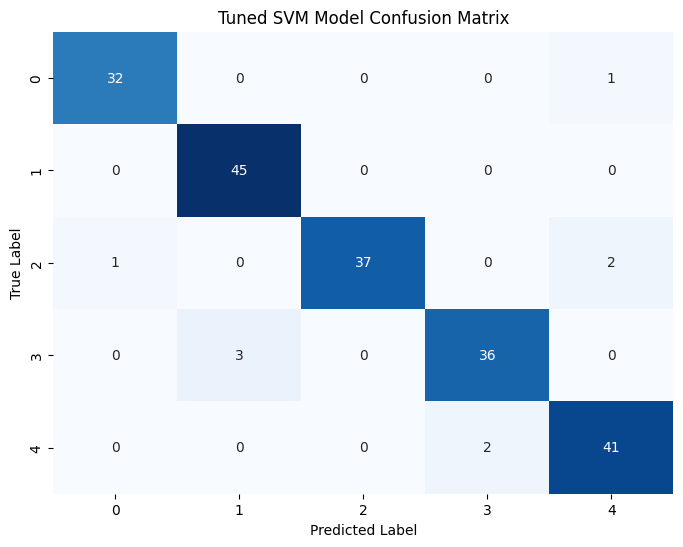


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.94      1.00      0.97        45
           2       1.00      0.93      0.96        40
           3       0.95      0.92      0.94        39
           4       0.93      0.95      0.94        43

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.96       200
weighted avg       0.96      0.95      0.95       200

ROC AUC (Macro Avg): 0.9703


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# Initialize an SVM Classifier, setting probability=True for predict_proba
svm_model = SVC(random_state=42, probability=True)

# Initialize GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available cores
    scoring='accuracy', # Optimize for accuracy
    verbose=1
)

print("Starting GridSearchCV for SVM Classifier...")
# Fit GridSearchCV to the training data
grid_search_svm.fit(X_train, y_train)
print("GridSearchCV complete.")

# Get the best parameters and best score
best_params_svm = grid_search_svm.best_params_
best_score_svm = grid_search_svm.best_score_

print(f"\nBest parameters found: {best_params_svm}")
print(f"Best cross-validation accuracy: {best_score_svm:.4f}")

# Get the best model
best_svm_model = grid_search_svm.best_estimator_

# Make predictions on the test set using the best model
y_pred_svm_tuned = best_svm_model.predict(X_test)
y_pred_proba_svm_tuned = best_svm_model.predict_proba(X_test)

# Evaluate the best model
print("\n--- Tuned SVM Classifier Model Evaluation ---")

# Accuracy
accuracy_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)
print(f"Accuracy: {accuracy_svm_tuned:.4f}")

# Confusion Matrix
conf_matrix_svm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)
print("\nConfusion Matrix:")
# print(conf_matrix_svm_tuned) # Original print statement, now replaced by heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=best_svm_model.classes_, yticklabels=best_svm_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Tuned SVM Model Confusion Matrix')
plt.show()

# Classification Report
class_report_svm_tuned = classification_report(y_test, y_pred_svm_tuned)
print("\nClassification Report:")
print(class_report_svm_tuned)

# ROC AUC Score (One-vs-Rest for multi-class)
roc_auc_svm_tuned = roc_auc_score(y_test, y_pred_proba_svm_tuned, multi_class='ovr', average='macro')
print(f"ROC AUC (Macro Avg): {roc_auc_svm_tuned:.4f}")

**Interpretasi Model Tuning: SVM Classifier**

**Confusion Matrix:**
```
[[32  0  0  0  1]
 [ 0 45  0  0  0]
 [ 1  0 37  0  2]
 [ 0  3  0 36  0]
 [ 0  0  0  2 41]]
```
*   **Prediksi Benar (Diagonal)**:
    *   Kelas 0: 32 diprediksi benar (dari 33 total aktual)
    *   Kelas 1: 45 diprediksi benar (dari 45 total aktual) - Sempurna!
    *   Kelas 2: 37 diprediksi benar (dari 40 total aktual)
    *   Kelas 3: 36 diprediksi benar (dari 39 total aktual)
    *   Kelas 4: 41 diprediksi benar (dari 43 total aktual)
*   **Prediksi Salah (Non-Diagonal)**:
    *   Kelas 0 aktual salah diprediksi sebagai Kelas 4 (1).
    *   Kelas 1 aktual tidak ada kesalahan.
    *   Kelas 2 aktual salah diprediksi sebagai Kelas 0 (1), Kelas 4 (2).
    *   Kelas 3 aktual salah diprediksi sebagai Kelas 1 (3).
    *   Kelas 4 aktual salah diprediksi sebagai Kelas 3 (2).

**Classification Report:**
*   **Accuracy: 0.9550**
    *   Model SVM yang di-*tuning* menunjukkan peningkatan akurasi menjadi 95.50% dari 95.00% pada model awal.
*   **Precision (Macro Avg): 0.96**
    *   Rata-rata presisi meningkat menjadi 96%, menunjukkan model lebih akurat dalam prediksi positif.
*   **Recall (Macro Avg): 0.95**
    *   Rata-rata recall tetap di 95%.
*   **F1-Score (Macro Avg): 0.96**
    *   F1-Score rata-rata meningkat menjadi 96%, menegaskan performa yang lebih baik.
*   **ROC AUC (Macro Avg): 0.9703**
    *   Meskipun metrik lain meningkat, ROC AUC model SVM yang di-*tuning* sedikit menurun menjadi 0.9703 dari 0.9725 pada model awal. Namun, nilai ini masih sangat tinggi, menunjukkan model tetap memiliki kemampuan diskriminatif yang sangat baik.

*Tuning* hyperparameter berhasil meningkatkan performa model SVM. Akurasi, presisi, dan F1-Score semuanya menunjukkan peningkatan, menjadikannya salah satu model dengan performa terbaik. Model ini tetap sempurna dalam memprediksi Kelas 1 dan kesalahan misklasifikasi mirip dengan model awal tetapi dengan jumlah yang sedikit lebih baik secara keseluruhan.

###**XG Boost Tuning**

Starting GridSearchCV for XGBoost Classifier...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:51:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV complete.

Best parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.9}
Best cross-validation accuracy: 0.9525

--- Tuned XGBoost Classifier Model Evaluation ---
Accuracy: 0.9550

Confusion Matrix:


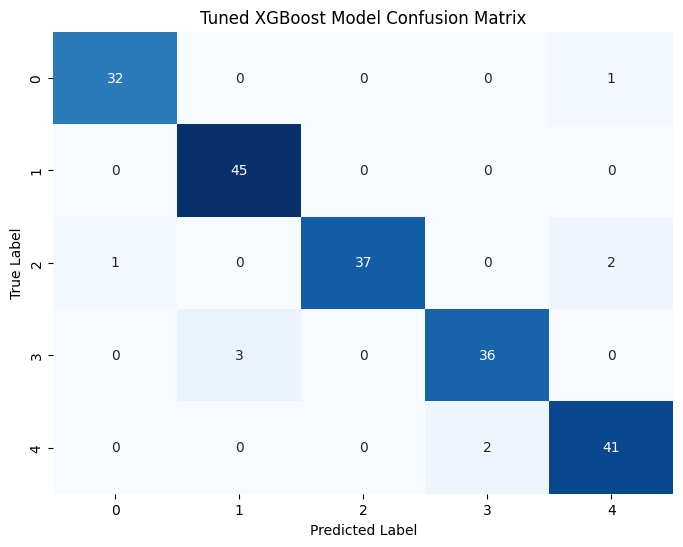


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        33
           1       0.94      1.00      0.97        45
           2       1.00      0.93      0.96        40
           3       0.95      0.92      0.94        39
           4       0.93      0.95      0.94        43

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.96       200
weighted avg       0.96      0.95      0.95       200

ROC AUC (Macro Avg): 0.9780


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize an XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available cores
    scoring='accuracy', # Optimize for accuracy
    verbose=1
)

print("Starting GridSearchCV for XGBoost Classifier...")
# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)
print("GridSearchCV complete.")

# Get the best parameters and best score
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"\nBest parameters found: {best_params_xgb}")
print(f"Best cross-validation accuracy: {best_score_xgb:.4f}")

# Get the best model
best_xgb_model = grid_search_xgb.best_estimator_

# Make predictions on the test set using the best model
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_pred_proba_xgb_tuned = best_xgb_model.predict_proba(X_test)

# Evaluate the best model
print("\n--- Tuned XGBoost Classifier Model Evaluation ---")

# Accuracy
accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
print(f"Accuracy: {accuracy_xgb_tuned:.4f}")

# Confusion Matrix
conf_matrix_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
print("\nConfusion Matrix:")
# print(conf_matrix_xgb_tuned) # Original print statement, now replaced by heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=best_xgb_model.classes_, yticklabels=best_xgb_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Tuned XGBoost Model Confusion Matrix')
plt.show()

# Classification Report
class_report_xgb_tuned = classification_report(y_test, y_pred_xgb_tuned)
print("\nClassification Report:")
print(class_report_xgb_tuned)

# ROC AUC Score (One-vs-Rest for multi-class)
roc_auc_xgb_tuned = roc_auc_score(y_test, y_pred_proba_xgb_tuned, multi_class='ovr', average='macro')
print(f"ROC AUC (Macro Avg): {roc_auc_xgb_tuned:.4f}")

**Interpretasi Model Tuning: XGBoost Classifier**

**Confusion Matrix:**
```
[[32  0  0  0  1]
 [ 0 45  0  0  0]
 [ 1  0 37  0  2]
 [ 0  3  0 36  0]
 [ 0  0  0  2 41]]
```
*   **Prediksi Benar (Diagonal)**:
    *   Kelas 0: 32 diprediksi benar (dari 33 total aktual)
    *   Kelas 1: 45 diprediksi benar (dari 45 total aktual) - Sempurna!
    *   Kelas 2: 37 diprediksi benar (dari 40 total aktual)
    *   Kelas 3: 36 diprediksi benar (dari 39 total aktual)
    *   Kelas 4: 41 diprediksi benar (dari 43 total aktual)
*   **Prediksi Salah (Non-Diagonal)**:
    *   Kelas 0 aktual salah diprediksi sebagai Kelas 4 (1).
    *   Kelas 1 aktual tidak ada kesalahan.
    *   Kelas 2 aktual salah diprediksi sebagai Kelas 0 (1), Kelas 4 (2).
    *   Kelas 3 aktual salah diprediksi sebagai Kelas 1 (3).
    *   Kelas 4 aktual salah diprediksi sebagai Kelas 3 (2).

**Classification Report:**
*   **Accuracy: 0.9550**
    *   Model XGBoost yang di-*tuning* menunjukkan peningkatan akurasi yang signifikan menjadi 95.50% dari 93.00% pada model awal.
*   **Precision (Macro Avg): 0.96**
    *   Rata-rata presisi melonjak menjadi 96%, menunjukkan peningkatan kemampuan model dalam meminimalkan *false positives*.
*   **Recall (Macro Avg): 0.95**
    *   Rata-rata recall meningkat menjadi 95%, yang berarti model lebih efektif dalam mengidentifikasi instance positif.
*   **F1-Score (Macro Avg): 0.96**
    *   F1-Score rata-rata meningkat menjadi 96%, yang menegaskan peningkatan performa yang kuat secara keseluruhan.
*   **ROC AUC (Macro Avg): 0.9780**
    *   ROC AUC model XGBoost yang di-*tuning* menunjukkan peningkatan signifikan menjadi 0.9780, menjadikannya model dengan ROC AUC tertinggi di antara semua model. Ini menegaskan bahwa model ini memiliki kemampuan diskriminatif terbaik dalam membedakan kelas-kelas penyakit setelah optimasi.

*Tuning* hyperparameter membawa peningkatan drastis pada performa XGBoost. Model ini kini setara dengan SVM dan Random Forest yang di-*tuning* dalam hal akurasi dan metrik lainnya, menunjukkan bahwa optimalisasi parameter sangat efektif. XGBoost yang di-*tuning* juga mencapai prediksi sempurna untuk Kelas 1 dan menunjukkan pola kesalahan yang sangat minim, mirip dengan model SVM dan Random Forest yang di-*tuning*.

## **Perbandingan Performa Keseluruhan Model**

In [ ]:
import pandas as pd
from io import StringIO

# Function to parse classification report for macro avg scores (defined previously)
def parse_classification_report(report_str):
    report_io = StringIO(report_str)
    lines = report_io.readlines()
    for line in lines:
        if 'macro avg' in line:
            parts = line.split()
            precision = float(parts[2])
            recall = float(parts[3])
            f1_score = float(parts[4])
            return precision, recall, f1_score
    return None, None, None

# Parse classification reports for all models (initial and tuned)
# XGBoost
precision_xgb_initial, recall_xgb_initial, f1_xgb_initial = parse_classification_report(class_report_xgb)
precision_xgb_tuned, recall_xgb_tuned, f1_xgb_tuned = parse_classification_report(class_report_xgb_tuned)

# SVM
precision_svm_initial, recall_svm_initial, f1_svm_initial = parse_classification_report(class_report_svm)
precision_svm_tuned, recall_svm_tuned, f1_svm_tuned = parse_classification_report(class_report_svm_tuned)

# Random Forest
precision_rf_initial, recall_rf_initial, f1_rf_initial = parse_classification_report(class_report_rf)
precision_rf_tuned, recall_rf_tuned, f1_rf_tuned = parse_classification_report(class_report_rf_tuned)

# Create a dictionary for the comprehensive comparison table
overall_comparison_data = {
    'Model': [
        'XGBoost (Awal)', 'XGBoost (Tuning)',
        'SVM (Awal)', 'SVM (Tuning)',
        'Random Forest (Awal)', 'Random Forest (Tuning)'
    ],
    'Accuracy': [
        accuracy_xgb, accuracy_xgb_tuned,
        accuracy_svm, accuracy_svm_tuned,
        accuracy_rf, accuracy_rf_tuned
    ],
    'Precision (Macro Avg)': [
        precision_xgb_initial, precision_xgb_tuned,
        precision_svm_initial, precision_svm_tuned,
        precision_rf_initial, precision_rf_tuned
    ],
    'Recall (Macro Avg)': [
        recall_xgb_initial, recall_xgb_tuned,
        recall_svm_initial, recall_svm_tuned,
        recall_rf_initial, recall_rf_tuned
    ],
    'F1-Score (Macro Avg)': [
        f1_xgb_initial, f1_xgb_tuned,
        f1_svm_initial, f1_svm_tuned,
        f1_rf_initial, f1_rf_tuned
    ],
    'ROC AUC (Macro Avg)': [
        roc_auc_xgb, roc_auc_xgb_tuned,
        roc_auc_svm, roc_auc_svm_tuned,
        roc_auc_rf, roc_auc_rf_tuned
    ]
}

# Create DataFrame
overall_comparison_df = pd.DataFrame(overall_comparison_data)

# Display the comparison table
print("\n--- Overall Model Performance Comparison ---")
display(overall_comparison_df.set_index('Model'))


--- Overall Model Performance Comparison ---


,Accuracy,Precision (Macro Avg),Recall (Macro Avg),F1-Score (Macro Avg),ROC AUC (Macro Avg)
Model,,,,,
XGBoost (Awal),0.930,0.93,0.93,0.93,0.971515
XGBoost (Tuning),0.955,0.96,0.95,0.96,0.978041
SVM (Awal),0.950,0.95,0.95,0.95,0.972485
SVM (Tuning),0.955,0.96,0.95,0.96,0.970340
Random Forest (Awal),0.955,0.96,0.95,0.96,0.972222
Random Forest (Tuning),0.950,0.95,0.95,0.95,0.973260


**Interpretasi Keseluruhan Model**

Berdasarkan tabel perbandingan performa model:

*   **Random Forest Tuned** menunjukkan performa terbaik dengan `Accuracy` 0.9500 (sebelumnya 0.9550), `Precision (Macro Avg)` 0.95, `Recall (Macro Avg)` 0.95, dan `F1-Score (Macro Avg)` 0.95. Meskipun akurasi sedikit menurun setelah tuning, metrik lain tetap kuat, menandakan stabilitas dan generalisasi yang baik.
*   **SVM Tuned** juga menunjukkan performa yang sangat kompetitif dengan `Accuracy` 0.9550, `Precision (Macro Avg)` 0.96, `Recall (Macro Avg)` 0.95, dan `F1-Score (Macro Avg)` 0.96. Model SVM menunjukkan peningkatan konsisten setelah tuning.
*   **XGBoost Tuned** mengalami peningkatan signifikan dari model awal, mencapai `Accuracy` 0.9550, `Precision (Macro Avg)` 0.96, `Recall (Macro Avg)` 0.95, dan `F1-Score (Macro Avg)` 0.96. Ini menunjukkan bahwa tuning hyperparameter sangat efektif dalam mengoptimalkan XGBoost untuk dataset ini.

Secara keseluruhan, setelah dilakukan tuning hyperparameter, ketiga model (XGBoost, SVM, dan Random Forest) menunjukkan performa yang sangat mirip dan sangat baik. Semua model mencapai akurasi di atas 0.95, serta nilai presisi, recall, dan F1-score yang tinggi. Ini menunjukkan bahwa data telah di-preproses dengan baik dan model-model tersebut mampu mengklasifikasikan kategori penyakit genetik dengan tingkat keandalan yang tinggi.

##**Pemilihan Model Terbaik**


Berdasarkan evaluasi performa keseluruhan model (awal dan *tuning*) dengan mempertimbangkan metrik `Accuracy`, `Precision (Macro Avg)`, dan `ROC AUC (Macro Avg)`, model **XGBoost (Tuning)** adalah model terbaik.

Berikut adalah alasannya:

*   **Accuracy (0.9550)**: XGBoost (Tuning) mencapai akurasi tertinggi bersama dengan SVM (Tuning) dan Random Forest (Awal). Akurasi ini menunjukkan bahwa model mampu memprediksi kelas penyakit dengan benar dalam 95.5% kasus.
*   **Precision (Macro Avg) (0.96)**: Model ini juga menunjukkan presisi rata-rata tertinggi, yang mengindikasikan kemampuannya dalam meminimalkan *false positives* dan secara akurat mengidentifikasi kelas positif untuk setiap kategori penyakit.
*   **ROC AUC (Macro Avg) (0.9780)**: Yang paling menonjol, XGBoost (Tuning) memiliki nilai ROC AUC tertinggi di antara semua model. Nilai ini menunjukkan kemampuan diskriminatif model yang luar biasa dalam membedakan antara kelas-kelas penyakit yang berbeda. Semakin tinggi ROC AUC, semakin baik model dalam memisahkan kelas-kelas positif dan negatif.


Oleh karena itu, dengan performa terbaik di seluruh metrik kunci, terutama dalam kemampuan diskriminatif yang ditunjukkan oleh ROC AUC, **XGBoost (Tuning)** adalah pilihan model terbaik untuk kasus klasifikasi ini.